# Import & Helpers

In [2]:
import sys
from importlib import reload
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
from importlib import reload

if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")
if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")

import noninteracting
from noninteracting import KagomeNagaosa
import interaction
import frg_kernel
import channels
import frg_flow
import patching
from patching import build_exactM_patchset, PatchPoint, PatchSet, plot_patchset, exact_M6_points_1bz

## Plot Helper

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import channels
import instability
import frg_flow
import interaction
import frg_kernel

from channels import SZ0ChannelBuilder
from instability import InstabilityConfig, diagnose_kernel_collection
from frg_flow import BareSZ0VertexFromInteraction, FRGFlowSolverSZ0
from frg_kernel import FlowConfig


# ============================================================
# Basic formatting / plotting helpers
# ============================================================

CHANNELS_ORDER = ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]


def fmt_q(q, nd=3):
    q = np.asarray(q, dtype=float)
    return f"({q[0]:.{nd}f}, {q[1]:.{nd}f})"


def hermitian_part(M):
    M = np.asarray(M, dtype=complex)
    return 0.5 * (M + M.conjugate().T)


def sign_aware_channel_score(channel_name, M):
    """
    Same logic as current solver sign-aware score:
      pp -> largest positive eigenvalue of Hermitian part
      ph -> absolute value of most negative eigenvalue of Hermitian part
    """
    H = hermitian_part(M)
    evals, _ = np.linalg.eigh(H)
    eval_pos_max = float(np.max(evals)) if evals.size else 0.0
    eval_neg_min = float(np.min(evals)) if evals.size else 0.0

    if channel_name.startswith("pp"):
        physical_score = max(eval_pos_max, 0.0)
        chosen_eval = eval_pos_max
        chosen_sign = "positive"
    elif channel_name.startswith("ph"):
        physical_score = max(-eval_neg_min, 0.0)
        chosen_eval = eval_neg_min
        chosen_sign = "negative"
    else:
        raise ValueError(f"Unknown channel name: {channel_name}")

    return {
        "eval_pos_max": eval_pos_max,
        "eval_neg_min": eval_neg_min,
        "physical_score": float(physical_score),
        "chosen_eval": float(chosen_eval),
        "chosen_sign": chosen_sign,
        "herm_resid": float(np.max(np.abs(M - M.conjugate().T))),
    }


def build_builder_from_solver(solver, *, Landau_F=None):
    if Landau_F is None:
        Landau_F = getattr(solver, "diagnosis_landau_F", False)
    return channels.SZ0ChannelBuilder.from_solver(
        solver.current_vertex_accessor(),
        solver,
        Landau_F=Landau_F,
    )


def evaluate_signaware_selected_Qs(builder, diagnosis_Qs, *, landau_F=False):
    rows = []
    kernel_store = {}

    for iq, Q in enumerate(diagnosis_Qs):
        Q = np.asarray(Q, dtype=float)
        kernel_dict = builder.build_kernel_dict(Q, Landau_F=landau_F)
        kernel_store[iq] = {"Q": Q.copy(), "kernels": kernel_dict}

        for ch_name, ker in kernel_dict.items():
            info = sign_aware_channel_score(ch_name, ker.matrix)
            rows.append({
                "channel": ch_name,
                "Q_index": int(iq),
                "Q": Q.copy(),
                "Qx": float(Q[0]),
                "Qy": float(Q[1]),
                **info,
            })

    df = pd.DataFrame(rows)
    return df, kernel_store


def evaluate_instability_selected_Qs(
    builder,
    solver,
    diagnosis_Qs,
    *,
    temperature=None,
    landau_F=False,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    rows = []
    result_store = {}

    if temperature is None:
        temperature = float(solver.state.T)

    cfg = InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=False,
        store_all_evals=False,

        # IMPORTANT: keep diagnosis consistent with current flow measure
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", 1e-8),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
    )

    flow_cfg = FlowConfig(
        temperature=float(temperature),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    for iq, Q in enumerate(diagnosis_Qs):
        Q = np.asarray(Q, dtype=float)
        kernel_dict = builder.build_kernel_dict(Q, Landau_F=landau_F)

        res_dict = diagnose_kernel_collection(
            kernel_dict,
            solver.patchsets,
            solver.transfer_context(),
            flow_cfg,
            config=cfg,
        )
        result_store[iq] = {"Q": Q.copy(), "results": res_dict}

        for ch_name, res in res_dict.items():
            rows.append({
                "channel": ch_name,
                "Q_index": int(iq),
                "Q": Q.copy(),
                "Qx": float(Q[0]),
                "Qy": float(Q[1]),
                "score": float(res.score),
                "leading_eval": float(res.leading_eval),
                "score_unprojected": float(res.score_unprojected),
                "score_projected": None if res.score_projected is None else float(res.score_projected),
                "projection_name": res.projection_name,
                "bubble_source": res.bubble.source,
                "channel_type": res.channel_type,
                "spin_structure": res.spin_structure,
            })

    df = pd.DataFrame(rows)
    return df, result_store


def leading_row_from_df(df, score_col):
    if len(df) == 0:
        raise ValueError("Empty dataframe.")
    return df.sort_values(score_col, ascending=False).iloc[0]


def plot_channel_bars(df, *, value_col, title, ylabel):
    df = df.copy()
    df["Q_key"] = df["Q"].apply(lambda x: tuple(np.asarray(x, dtype=float)))
    q_keys = list(dict.fromkeys(df["Q_key"].tolist()))
    q_labels = [f"Q{i}:{fmt_q(np.array(qk))}" for i, qk in enumerate(q_keys)]

    x = np.arange(len(q_keys))
    width = 0.18

    fig, ax = plt.subplots(figsize=(11, 5))
    for j, ch in enumerate(CHANNELS_ORDER):
        vals = []
        for qk in q_keys:
            sub = df[(df["channel"] == ch) & (df["Q_key"] == qk)]
            vals.append(float(sub.iloc[0][value_col]) if len(sub) else 0.0)
        ax.bar(x + (j - 1.5) * width, vals, width=width, label=ch)

    ax.set_xticks(x)
    ax.set_xticklabels(q_labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Flow Helper

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Helpers: dataframe shaping / printing / plotting
# ============================================================

def _is_q0_vec(q, tol=1e-10):
    q = np.asarray(q, dtype=float)
    return bool(np.allclose(q, 0.0, atol=tol, rtol=0.0))


def _scores_at_qindex(df, q_index, value_col, channels_order=CHANNELS_ORDER):
    sub = df[df["Q_index"] == int(q_index)]
    out = {}
    for ch in channels_order:
        ss = sub[sub["channel"] == ch]
        out[ch] = float(ss.iloc[0][value_col]) if len(ss) else np.nan
    return out


def _leading_row(df, value_col):
    if len(df) == 0:
        raise ValueError("Empty dataframe.")
    return df.sort_values(value_col, ascending=False).iloc[0]


def _format_channel_scores(score_map, channels_order=CHANNELS_ORDER):
    parts = []
    for ch in channels_order:
        val = score_map.get(ch, np.nan)
        if np.isfinite(val):
            parts.append(f"{ch}={val:.3e}")
        else:
            parts.append(f"{ch}=nan")
    return ", ".join(parts)


def _append_step_rows(storage, df, *, step_index, T, family):
    for _, row in df.iterrows():
        storage.append({
            "family": family,  # "kernel" or "instability"
            "step_index": int(step_index),
            "T": float(T),
            "Q_index": int(row["Q_index"]),
            "Q": np.asarray(row["Q"], dtype=float),
            "Qx": float(row["Qx"]),
            "Qy": float(row["Qy"]),
            "channel": str(row["channel"]),
            "value": float(row["physical_score"] if family == "kernel" else row["score"]),
        })


def _collapse_q_groups(history_df, *, q0_tol=1e-10):
    """
    Collapse selected Qs into two groups:
      - Q0 : exact q=0
      - QM : max over all nonzero selected Q's
    """
    rows = []
    for (family, step_index, T, channel), sub in history_df.groupby(["family", "step_index", "T", "channel"]):
        sub = sub.copy()
        q0_mask = sub["Q"].apply(lambda x: _is_q0_vec(x, tol=q0_tol)).values

        # Q=0
        sub_q0 = sub[q0_mask]
        q0_val = np.nan
        if len(sub_q0):
            q0_val = float(np.max(sub_q0["value"].values))
        rows.append({
            "family": family,
            "step_index": int(step_index),
            "T": float(T),
            "channel": channel,
            "Q_group": "Q0",
            "value": q0_val,
        })

        # Q=M group = max over all nonzero chosen Qs
        sub_qm = sub[~q0_mask]
        qm_val = np.nan
        if len(sub_qm):
            qm_val = float(np.max(sub_qm["value"].values))
        rows.append({
            "family": family,
            "step_index": int(step_index),
            "T": float(T),
            "channel": channel,
            "Q_group": "QM",
            "value": qm_val,
        })

    out = pd.DataFrame(rows).sort_values(["family", "Q_group", "step_index", "channel"]).reset_index(drop=True)
    return out


def plot_flow_group_curves(
    grouped_df,
    *,
    last_n_steps=None,
    ylog=True,
    title_prefix="RG flow",
    ylim=1e-2
):
    """
    Produce exactly 4 plots:
      1. Q=0 kernel score vs T
      2. Q=M kernel score vs T
      3. Q=0 instability score vs T
      4. Q=M instability score vs T
    """
    df = grouped_df.copy()

    if last_n_steps is not None:
        keep_steps = sorted(df["step_index"].unique())[-int(last_n_steps):]
        df = df[df["step_index"].isin(keep_steps)].copy()

    panels = [
        ("kernel", "Q0", "sign-aware kernel score"),
        ("kernel", "QM", "sign-aware kernel score"),
        ("instability", "Q0", "physical instability score"),
        ("instability", "QM", "physical instability score"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    for ax, (family, q_group, ylabel) in zip(axes, panels):
        sub = df[(df["family"] == family) & (df["Q_group"] == q_group)].copy()

        for ch in CHANNELS_ORDER:
            ss = sub[sub["channel"] == ch].sort_values("step_index")
            if len(ss) == 0:
                continue

            y = ss["value"].to_numpy(dtype=float)
            x = ss["T"].to_numpy(dtype=float)

            if ylog:
                y = np.where(y > 0, y, np.nan)
                ax.set_yscale("log")

            ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=ch)

        ax.set_title(f"{title_prefix}: {family} / {q_group}")
        ax.set_xlabel("Temperature")
        ax.set_ylabel(ylabel)
        ax.set_ylim(bottom=ylim)
        ax.grid(True, alpha=0.3)
        ax.invert_xaxis()
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


def print_flow_step_summary(
    *,
    step_index,
    T,
    rhs_norm,
    signaware_df,
    instab_df,
):
    lead_kernel = _leading_row(signaware_df, "physical_score")
    lead_instab = _leading_row(instab_df, "score")

    lead_qi_kernel = int(lead_kernel["Q_index"])
    lead_qi_instab = int(lead_instab["Q_index"])

    kernel_scores_at_leadQ = _scores_at_qindex(signaware_df, lead_qi_kernel, "physical_score")
    instab_scores_at_leadQ = _scores_at_qindex(instab_df, lead_qi_instab, "score")

    print(
        f"step={step_index:4d} | "
        f"T={T:.6f} | rhs_norm={rhs_norm:.3e} | "
        f"lead_kernel={lead_kernel['channel']} @ Q{lead_qi_kernel}:{fmt_q(lead_kernel['Q'])} "
        f"score={float(lead_kernel['physical_score']):.3e}"
    )
    print("kernel scores:", _format_channel_scores(kernel_scores_at_leadQ))
    print(
        f"    lead_instability={lead_instab['channel']} @ Q{lead_qi_instab}:{fmt_q(lead_instab['Q'])} "
        f"score={float(lead_instab['score']):.3e}"
    )
    print("instability:", _format_channel_scores(instab_scores_at_leadQ))


def run_flow_with_tracking(
    solver,
    diagnosis_Qs,
    *,
    print_every=1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    """
    Manual RG flow with per-step diagnostics:
      - sign-aware kernel score
      - physical instability score

    Returns
    -------
    history : list[FlowStepRecord]
    signaware_history_df : pd.DataFrame
    instability_history_df : pd.DataFrame
    grouped_plot_df : pd.DataFrame
    """
    temps = solver.temperature_path
    signaware_rows = []
    instab_rows = []

    # -------------------------------
    # step 0
    # -------------------------------
    rec0 = frg_flow.FlowStepRecord(
        step_index=0,
        temperature=float(temps[0]),
        dT=0.0,
        channel_norm=solver.state.channel_norm(),
        rhs_norm=0.0,
        accepted_substeps=0,
        max_rel_update=0.0,
        diagnosis_payload=solver.diagnose_current_state(),
    )
    rec0.instability, rec0.instability_reason = solver.check_instability(rec0)
    solver.history = [rec0]
    solver.instability_record = rec0 if rec0.instability else None

    builder0 = build_builder_from_solver(solver, Landau_F=False)

    sign_df0, _ = evaluate_signaware_selected_Qs(builder0, diagnosis_Qs, landau_F=False)
    instab_df0, _ = evaluate_instability_selected_Qs(
        builder0,
        solver,
        diagnosis_Qs,
        temperature=float(temps[0]),
        landau_F=False,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
    )

    _append_step_rows(signaware_rows, sign_df0, step_index=0, T=float(temps[0]), family="kernel")
    _append_step_rows(instab_rows, instab_df0, step_index=0, T=float(temps[0]), family="instability")

    print_flow_step_summary(
        step_index=0,
        T=float(temps[0]),
        rhs_norm=0.0,
        signaware_df=sign_df0,
        instab_df=instab_df0,
    )

    if rec0.instability:
        print("\n[flow stopped at step 0]")
        print("reason:", rec0.instability_reason)
        signaware_history_df = pd.DataFrame(signaware_rows)
        instability_history_df = pd.DataFrame(instab_rows)
        grouped_plot_df = _collapse_q_groups(pd.concat([signaware_history_df, instability_history_df], ignore_index=True))
        return solver.history, signaware_history_df, instability_history_df, grouped_plot_df

    # -------------------------------
    # main loop
    # -------------------------------
    for i in range(len(temps) - 1):
        T_old = float(temps[i])
        T_new = float(temps[i + 1])

        rec = solver.step(T_old, T_new - T_old)
        rec.instability, rec.instability_reason = solver.check_instability(rec)
        solver.history.append(rec)

        builder = build_builder_from_solver(solver, Landau_F=False)

        sign_df, _ = evaluate_signaware_selected_Qs(builder, diagnosis_Qs, landau_F=False)
        instab_df, _ = evaluate_instability_selected_Qs(
            builder,
            solver,
            diagnosis_Qs,
            temperature=rec.temperature,
            landau_F=False,
            ph_bubble_mode=ph_bubble_mode,
            project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
            project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        )

        _append_step_rows(signaware_rows, sign_df, step_index=rec.step_index, T=rec.temperature, family="kernel")
        _append_step_rows(instab_rows, instab_df, step_index=rec.step_index, T=rec.temperature, family="instability")

        if (rec.step_index % int(print_every) == 0) or rec.instability or rec.terminated_early:
            print_flow_step_summary(
                step_index=rec.step_index,
                T=rec.temperature,
                rhs_norm=rec.rhs_norm,
                signaware_df=sign_df,
                instab_df=instab_df,
            )

        if rec.instability:
            solver.instability_record = rec
            print("\n[flow stopped]")
            if rec.instability_reason is not None:
                print("instability_reason:", rec.instability_reason)
            if rec.termination_reason is not None:
                print("termination_reason:", rec.termination_reason)
            break

    signaware_history_df = pd.DataFrame(signaware_rows)
    instability_history_df = pd.DataFrame(instab_rows)
    grouped_plot_df = _collapse_q_groups(
        pd.concat([signaware_history_df, instability_history_df], ignore_index=True)
    )

    return solver.history, signaware_history_df, instability_history_df, grouped_plot_df

def run_flow_with_tracking_and_snapshots(
    solver,
    diagnosis_Qs,
    *,
    print_every=1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    temps = solver.temperature_path
    signaware_rows = []
    instab_rows = []
    snapshots = {}

    # step 0
    rec0 = frg_flow.FlowStepRecord(
        step_index=0,
        temperature=float(temps[0]),
        dT=0.0,
        channel_norm=solver.state.channel_norm(),
        rhs_norm=0.0,
        accepted_substeps=0,
        max_rel_update=0.0,
        diagnosis_payload=solver.diagnose_current_state(),
    )
    rec0.instability, rec0.instability_reason = solver.check_instability(rec0)
    solver.history = [rec0]
    solver.instability_record = rec0 if rec0.instability else None

    snapshots[0] = make_snapshot_from_solver(solver, label="step_0")

    builder0 = build_builder_from_solver(solver, Landau_F=False)
    sign_df0, _ = evaluate_signaware_selected_Qs(builder0, diagnosis_Qs, landau_F=False)
    instab_df0, _ = evaluate_instability_selected_Qs(
        builder0,
        solver,
        diagnosis_Qs,
        temperature=float(temps[0]),
        landau_F=False,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
    )

    _append_step_rows(signaware_rows, sign_df0, step_index=0, T=float(temps[0]), family="kernel")
    _append_step_rows(instab_rows, instab_df0, step_index=0, T=float(temps[0]), family="instability")

    print_flow_step_summary(
        step_index=0,
        T=float(temps[0]),
        rhs_norm=0.0,
        signaware_df=sign_df0,
        instab_df=instab_df0,
    )

    if rec0.instability:
        signaware_history_df = pd.DataFrame(signaware_rows)
        instability_history_df = pd.DataFrame(instab_rows)
        grouped_plot_df = _collapse_q_groups(pd.concat([signaware_history_df, instability_history_df], ignore_index=True))
        return solver.history, signaware_history_df, instability_history_df, grouped_plot_df, snapshots

    for i in range(len(temps) - 1):
        T_old = float(temps[i])
        T_new = float(temps[i + 1])

        rec = solver.step(T_old, T_new - T_old)
        rec.instability, rec.instability_reason = solver.check_instability(rec)
        solver.history.append(rec)

        snapshots[int(rec.step_index)] = make_snapshot_from_solver(
            solver, label=f"step_{rec.step_index}"
        )

        builder = build_builder_from_solver(solver, Landau_F=False)

        sign_df, _ = evaluate_signaware_selected_Qs(builder, diagnosis_Qs, landau_F=False)
        instab_df, _ = evaluate_instability_selected_Qs(
            builder,
            solver,
            diagnosis_Qs,
            temperature=rec.temperature,
            landau_F=False,
            ph_bubble_mode=ph_bubble_mode,
            project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
            project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        )

        _append_step_rows(signaware_rows, sign_df, step_index=rec.step_index, T=rec.temperature, family="kernel")
        _append_step_rows(instab_rows, instab_df, step_index=rec.step_index, T=rec.temperature, family="instability")

        if (rec.step_index % int(print_every) == 0) or rec.instability or rec.terminated_early:
            print_flow_step_summary(
                step_index=rec.step_index,
                T=rec.temperature,
                rhs_norm=rec.rhs_norm,
                signaware_df=sign_df,
                instab_df=instab_df,
            )

        if rec.instability:
            solver.instability_record = rec
            print("\n[flow stopped]")
            if rec.instability_reason is not None:
                print("instability_reason:", rec.instability_reason)
            if rec.termination_reason is not None:
                print("termination_reason:", rec.termination_reason)
            break

    signaware_history_df = pd.DataFrame(signaware_rows)
    instability_history_df = pd.DataFrame(instab_rows)
    grouped_plot_df = _collapse_q_groups(
        pd.concat([signaware_history_df, instability_history_df], ignore_index=True)
    )

    return solver.history, signaware_history_df, instability_history_df, grouped_plot_df, snapshots

## Diagnosis Helper

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Step selection helpers
# ============================================================
def summarize_eigenvector_against_constant(eigvec):
    v = np.asarray(eigvec, dtype=complex)
    n = len(v)
    v = v / np.linalg.norm(v)

    u_const = np.ones(n, dtype=complex) / np.sqrt(float(n))
    overlap = np.vdot(u_const, v)

    return {
        "eigvec": v,
        "const_vec": u_const,
        "const_overlap_abs": float(np.abs(overlap)),
        "const_overlap_complex": overlap,
    }


def plot_kernel_eigenstate_components(
    kernel_matrix,
    channel_name,
    Q,
    *,
    title_prefix="Kernel eigenstate components",
):
    eigval, eigvec = choose_signaware_eigenpair(channel_name, kernel_matrix)
    info = summarize_eigenvector_against_constant(eigvec)

    v = info["eigvec"]
    u_const = info["const_vec"]
    overlap_abs = info["const_overlap_abs"]

    idx = np.arange(len(v))
    amp = np.abs(v)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    # left: Re / Im vs patch index
    axes[0].plot(idx, np.real(v), marker="o", linewidth=1.5, label="Re(v)")
    axes[0].plot(idx, np.imag(v), marker="s", linewidth=1.5, label="Im(v)")
    axes[0].plot(idx, np.real(u_const), linestyle=":", linewidth=1.5, color="black", label="constant vector")
    axes[0].set_xlabel("patch index")
    axes[0].set_ylabel("component")
    axes[0].set_title(
        f"{title_prefix}\n{channel_name} @ Q={fmt_q(Q)} | chosen eval={eigval:.3e}\n"
        f"|<u_const|v>| = {overlap_abs:.6f}"
    )
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # right: |component|
    axes[1].bar(idx, amp)
    axes[1].set_xlabel("patch index")
    axes[1].set_ylabel("|component|")
    axes[1].set_title("Absolute component weight of leading eigenstate")
    axes[1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n=== leader eigenstate summary ===")
    print("channel            :", channel_name)
    print("Q                  :", fmt_q(Q, nd=6))
    print("selected eigenvalue:", f"{eigval:.12e}")
    print("kernel dimension   :", len(v))
    print("|<u_const|v>|      :", f"{overlap_abs:.12e}")

    return eigval, eigvec, info

def resolve_history_step(history, step_selector=-1):
    """
    step_selector:
      - negative int: Python-style indexing from the end
      - nonnegative int: exact step_index lookup if possible, else positional fallback
    """
    if len(history) == 0:
        raise ValueError("History is empty.")

    if isinstance(step_selector, (int, np.integer)):
        step_selector = int(step_selector)

        # negative -> python indexing
        if step_selector < 0:
            rec = history[step_selector]
            return rec

        # first try exact step_index
        for rec in history:
            if int(rec.step_index) == step_selector:
                return rec

        # fallback: positional
        if 0 <= step_selector < len(history):
            return history[step_selector]

    raise ValueError(f"Could not resolve step_selector={step_selector!r}")


# ============================================================
# Snapshot helpers
# ============================================================

from dataclasses import dataclass

@dataclass
class VertexSnapshot:
    label: str
    T: float
    data: np.ndarray
    p4_index: np.ndarray
    p4_residual: np.ndarray


def make_snapshot_from_solver(solver, label):
    return VertexSnapshot(
        label=label,
        T=float(solver.state.T),
        data=np.array(solver.state.vertex.data, dtype=complex, copy=True),
        p4_index=np.array(solver.state.vertex.p4_index, dtype=int, copy=True),
        p4_residual=np.array(solver.state.vertex.p4_residual, dtype=float, copy=True),
    )


def make_snapshot_from_history_record(solver, rec, label=None):
    """
    Build a snapshot from the CURRENT solver state only if the solver is already
    sitting at that record's state. This helper is mostly for the last step.

    For arbitrary historical steps, use stored snapshots if you saved them during flow.
    """
    if label is None:
        label = f"step_{rec.step_index}"
    return make_snapshot_from_solver(solver, label=label)


def make_snapshot_accessor(snapshot, solver):
    data = np.asarray(snapshot.data, dtype=complex)
    p4_index = np.asarray(snapshot.p4_index, dtype=int)
    p4_residual = np.asarray(snapshot.p4_residual, dtype=float)

    closure_tol = getattr(solver, "closure_tol", None)
    drop_inexact_closure = bool(getattr(solver, "drop_inexact_closure", False))

    def closure_is_valid(p1, p2, p3):
        if not drop_inexact_closure:
            return True
        if closure_tol is None:
            return True
        return bool(float(p4_residual[p1, p2, p3]) <= float(closure_tol))

    def accessor(p1, p2, p3, p4):
        p4_expected = int(p4_index[p1, p2, p3])
        if p4_expected < 0 or int(p4) != p4_expected:
            return 0.0 + 0.0j
        if not closure_is_valid(p1, p2, p3):
            return 0.0 + 0.0j
        return complex(data[p1, p2, p3])

    return accessor


def make_builder_from_snapshot(snapshot, solver, *, Landau_F=False):
    return channels.SZ0ChannelBuilder.from_solver(
        make_snapshot_accessor(snapshot, solver),
        solver,
        Landau_F=Landau_F,
    )


# ============================================================
# Diagnosis on one snapshot
# ============================================================

def diagnose_snapshot_signaware(snapshot, solver, diagnosis_Qs, *, landau_F=False):
    builder = make_builder_from_snapshot(snapshot, solver, Landau_F=landau_F)
    df, kernel_store = evaluate_signaware_selected_Qs(builder, diagnosis_Qs, landau_F=landau_F)
    return df, kernel_store, builder


def diagnose_snapshot_instability(
    snapshot,
    solver,
    diagnosis_Qs,
    *,
    landau_F=False,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    builder = make_builder_from_snapshot(snapshot, solver, Landau_F=landau_F)

    cfg = instability.InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=False,
        store_all_evals=False,

        # keep consistent with solver flow measure
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", 1e-8),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
    )

    flow_cfg = frg_kernel.FlowConfig(
        temperature=float(snapshot.T),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    rows = []
    result_store = {}

    for iq, Q in enumerate(diagnosis_Qs):
        kernel_dict = builder.build_kernel_dict(np.asarray(Q, dtype=float), Landau_F=landau_F)

        res_dict = instability.diagnose_kernel_collection(
            kernel_dict,
            solver.patchsets,
            solver.transfer_context(),
            flow_cfg,
            config=cfg,
        )
        result_store[iq] = {"Q": np.asarray(Q, dtype=float), "results": res_dict}

        for ch_name, res in res_dict.items():
            rows.append({
                "channel": ch_name,
                "Q_index": int(iq),
                "Q": np.asarray(Q, dtype=float),
                "Qx": float(Q[0]),
                "Qy": float(Q[1]),
                "score": float(res.score),
                "leading_eval": float(res.leading_eval),
                "score_unprojected": float(res.score_unprojected),
                "score_projected": None if res.score_projected is None else float(res.score_projected),
                "projection_name": res.projection_name,
                "bubble_source": res.bubble.source,
                "channel_type": res.channel_type,
                "spin_structure": res.spin_structure,
            })

    df = pd.DataFrame(rows)
    return df, result_store, builder


# ============================================================
# Eigenvector distribution helpers
# ============================================================

def choose_signaware_eigenpair(channel_name, M):
    H = hermitian_part(M)
    evals, evecs = np.linalg.eigh(H)

    if channel_name.startswith("pp"):
        idx = int(np.argmax(evals))
    elif channel_name.startswith("ph"):
        idx = int(np.argmin(evals))
    else:
        raise ValueError(f"Unknown channel_name={channel_name}")

    val = float(np.real(evals[idx]))
    vec = np.asarray(evecs[:, idx], dtype=complex)
    nrm = np.linalg.norm(vec)
    if nrm > 0:
        vec = vec / nrm
    return val, vec


def plot_kernel_eigenstate_distribution(
    kernel_matrix,
    channel_name,
    Q,
    patchsets,
    *,
    title_prefix="Kernel eigenstate distribution",
    annotate=True,
):
    eigval, eigvec = choose_signaware_eigenpair(channel_name, kernel_matrix)

    ps = patchsets["up"]
    ks = np.asarray([p.k_cart for p in ps.patches], dtype=float)

    amp = np.abs(eigvec)
    phase = np.angle(eigvec)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # amplitude
    sc0 = axes[0].scatter(ks[:, 0], ks[:, 1], c=amp, s=120, cmap="viridis")
    if annotate:
        for i, (x, y) in enumerate(ks):
            axes[0].text(x, y, str(i), fontsize=8, ha="left", va="bottom")
    axes[0].set_title(
        f"{title_prefix}\n{channel_name} @ Q={fmt_q(Q)} | chosen eval={eigval:.3e}\n|evec|"
    )
    axes[0].set_xlabel(r"$k_x$")
    axes[0].set_ylabel(r"$k_y$")
    axes[0].set_aspect("equal")
    plt.colorbar(sc0, ax=axes[0])

    # phase
    sc1 = axes[1].scatter(ks[:, 0], ks[:, 1], c=phase, s=120, cmap="twilight", vmin=-np.pi, vmax=np.pi)
    if annotate:
        for i, (x, y) in enumerate(ks):
            axes[1].text(x, y, str(i), fontsize=8, ha="left", va="bottom")
    axes[1].set_title(
        f"{title_prefix}\n{channel_name} @ Q={fmt_q(Q)} | chosen eval={eigval:.3e}\nphase(evec)"
    )
    axes[1].set_xlabel(r"$k_x$")
    axes[1].set_ylabel(r"$k_y$")
    axes[1].set_aspect("equal")
    plt.colorbar(sc1, ax=axes[1])

    plt.tight_layout()
    plt.show()

    return eigval, eigvec


# ============================================================
# High-level one-step diagnosis wrapper
# ============================================================

def diagnose_flowed_step(
    solver,
    history,
    diagnosis_Qs,
    *,
    step_selector=-1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    plot_eigenstate=True,
):
    rec = resolve_history_step(history, step_selector=step_selector)
    if "snapshots" not in globals():
        raise ValueError("No snapshots found. Re-run the flow cell that stores snapshots.")
    
    if int(rec.step_index) not in snapshots:
        raise ValueError(f"Snapshot for step {rec.step_index} not found.")
    
    snapshot = snapshots[int(rec.step_index)]
    print(f"Diagnosing step_index = {rec.step_index}")
    print(f"T = {rec.temperature:.6f}")
    print(f"rhs_norm = {rec.rhs_norm:.3e}")
    print(f"channel_norm = {rec.channel_norm:.3e}")
    print(f"instability = {rec.instability}")
    print(f"terminated_early = {rec.terminated_early}")
    print(f"instability_reason = {rec.instability_reason}")
    print(f"termination_reason = {rec.termination_reason}")

    # sign-aware
    df_sign, sign_store, sign_builder = diagnose_snapshot_signaware(
        snapshot, solver, diagnosis_Qs, landau_F=False
    )

    # instability
    df_inst, inst_store, inst_builder = diagnose_snapshot_instability(
        snapshot,
        solver,
        diagnosis_Qs,
        landau_F=False,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
    )

    # leaders
    best_sign = leading_row_from_df(df_sign, "physical_score")
    best_inst = leading_row_from_df(df_inst, "score")

    print("\n=== sign-aware leader at selected step ===")
    print("channel :", best_sign["channel"])
    print("Q       :", fmt_q(best_sign["Q"], nd=6))
    print("score   :", f"{best_sign['physical_score']:.12e}")
    print("chosen  :", best_sign["chosen_sign"], f"{best_sign['chosen_eval']:.12e}")

    print("\n=== physical-instability leader at selected step ===")
    print("channel :", best_inst["channel"])
    print("Q       :", fmt_q(best_inst["Q"], nd=6))
    print("score   :", f"{best_inst['score']:.12e}")
    print("eval    :", f"{best_inst['leading_eval']:.12e}")
    print("bubble  :", best_inst["bubble_source"])
    print("proj    :", best_inst["projection_name"])

    # plots 1 and 2
    plot_channel_bars(
        df_sign,
        value_col="physical_score",
        title=f"Flowed step {rec.step_index}: sign-aware kernel score on selected Q's",
        ylabel="sign-aware physical score",
    )

    plot_channel_bars(
        df_inst,
        value_col="score",
        title=f"Flowed step {rec.step_index}: physical instability score on selected Q's",
        ylabel="instability score",
    )

    # plot 3: eigenstate distribution of the leading sign-aware kernel
    eig_info = None
    if plot_eigenstate:
        lead_qi = int(best_sign["Q_index"])
        lead_q = np.asarray(best_sign["Q"], dtype=float)
        lead_channel = str(best_sign["channel"])

        lead_kernel = sign_store[lead_qi]["kernels"][lead_channel]
        eigval1, eigvec1 = plot_kernel_eigenstate_distribution(
            lead_kernel.matrix,
            lead_channel,
            lead_q,
            solver.patchsets,
            title_prefix=f"Step {rec.step_index}",
            annotate=True,
        )
        
        eigval2, eigvec2, eig_summary = plot_kernel_eigenstate_components(
            lead_kernel.matrix,
            lead_channel,
            lead_q,
            title_prefix=f"Step {rec.step_index}",
        )
        
        eig_info = {
            "channel": lead_channel,
            "Q_index": lead_qi,
            "Q": lead_q,
            "eigval": eigval1,
            "eigvec": eigvec1,
            "summary": eig_summary,
        }

    return {
        "record": rec,
        "snapshot": snapshot,
        "df_signaware": df_sign,
        "df_instability": df_inst,
        "sign_store": sign_store,
        "instability_store": inst_store,
        "eigenstate_info": eig_info,
    }

In [40]:
# ============================================================
# Helpers: PH diagnosis using candidate_diagnosis_unified
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

import channels as channels_mod
import instability as instability_mod
import candidate_diagnosis as cand_mod

importlib.reload(channels_mod)
importlib.reload(instability_mod)
importlib.reload(cand_mod)

from instability import FlowConfig, InstabilityConfig, diagnose_kernel_collection


def _normalize_vec(v, tol=1e-30):
    v = np.asarray(v, dtype=complex).reshape(-1)
    nrm = np.linalg.norm(v)
    if nrm <= tol:
        return np.zeros_like(v)
    return v / nrm


def _hermitian(M):
    M = np.asarray(M, dtype=complex)
    return 0.5 * (M + M.conjugate().T)


def _overlap2(v1, v2):
    v1 = _normalize_vec(v1)
    v2 = _normalize_vec(v2)
    return float(np.abs(np.vdot(v1, v2)) ** 2)


def _allclose_zero(q, tol=1e-10):
    q = np.asarray(q, dtype=float)
    return np.allclose(q, 0.0, atol=tol, rtol=0.0)


def _leading_eigpair_hermitian(M):
    H = _hermitian(M)
    vals, vecs = np.linalg.eigh(H)
    idx = int(np.argmax(np.real(vals)))
    return float(np.real(vals[idx])), _normalize_vec(vecs[:, idx])


def _orthonormalize_basis(vecs, tol=1e-30):
    basis = []
    for v in vecs:
        w = _normalize_vec(v)
        for b in basis:
            w = w - np.vdot(b, w) * b
        nrm = np.linalg.norm(w)
        if nrm > tol:
            basis.append(w / nrm)
    return basis


def _best_score_in_subspace(M, basis):
    basis = _orthonormalize_basis(basis)
    if len(basis) == 0:
        raise ValueError("Candidate subspace has zero rank.")
    B = np.column_stack(basis)
    Msub = _hermitian(B.conjugate().T @ M @ B)
    vals, vecs = np.linalg.eigh(Msub)
    idx = int(np.argmax(np.real(vals)))
    best_score = float(np.real(vals[idx]))
    best_vec = _normalize_vec(B @ vecs[:, idx])
    return best_score, best_vec


def _default_instability_config_from_solver(solver):
    return InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        ph_bubble_mode="patchrep",
        project_ph_charge_q0_uniform=True,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=False,
        store_operator_matrices=True,
        store_all_evals=False,
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", None),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
        analyze_multiplets=True,
        multiplet_top_n=6,
        multiplet_eval_rel_floor=1e-6,
        build_complex_candidates=True,
        max_complex_pairs_per_multiplet=1,
    )


def _build_kernel_and_instability_dict(
    solver,
    Q,
    instability_cfg,
    *,
    snapshot=None,
    Landau_F_for_channel_build=False,
):
    if snapshot is None:
        builder = solver._build_channel_builder()
        T_here = float(solver.state.T)
    else:
        builder = make_builder_from_snapshot(
            snapshot,
            solver,
            Landau_F=Landau_F_for_channel_build,
        )
        T_here = float(snapshot.T)

    kernel_dict = builder.build_kernel_dict(
        Q,
        Landau_F=Landau_F_for_channel_build,
    )

    flow_cfg = FlowConfig(
        temperature=T_here,
        nfreq=int(solver.nfreq),
        include_explicit_T_prefactor=bool(solver.include_explicit_T_prefactor),
    )

    instab_dict = diagnose_kernel_collection(
        kernel_dict,
        solver.patchsets,
        solver.transfer_context(),
        flow_cfg,
        config=instability_cfg,
    )

    return kernel_dict, instab_dict


def _resolve_snapshot_and_record(history, snapshots, step_selector=-1):
    rec = resolve_history_step(history, step_selector=step_selector)

    if isinstance(snapshots, dict):
        snap = snapshots[int(rec.step_index)]
    else:
        idx = next(
            i for i, r in enumerate(history)
            if int(r.step_index) == int(rec.step_index)
        )
        snap = snapshots[idx]

    return rec, snap


def _analysis_matrix_from_result(ker, res, *, use_operator=True):
    if not use_operator:
        return _hermitian(ker.matrix)
    if res.operator_unprojected is not None:
        return np.asarray(res.operator_unprojected, dtype=complex)
    return _hermitian(ker.matrix)


def _choose_best_QM_for_ph(
    solver,
    QM_list,
    instability_cfg,
    *,
    snapshot=None,
    Landau_F_for_channel_build=False,
):
    best_score = None
    best_Q = None

    for Qm in QM_list:
        _, idict_m = _build_kernel_and_instability_dict(
            solver,
            Qm,
            instability_cfg,
            snapshot=snapshot,
            Landau_F_for_channel_build=Landau_F_for_channel_build,
        )

        score = max(
            float(idict_m["ph_charge"].score),
            float(idict_m["ph_spin"].score),
        )

        if best_score is None or score > best_score:
            best_score = score
            best_Q = np.asarray(Qm, dtype=float)

    return best_Q


def _notebook_model():
    if "model" in globals():
        return globals()["model"]
    raise RuntimeError("Global `model` is not defined in this notebook.")


def _solver_up_patchset(solver):
    if hasattr(solver, "patchsets"):
        if "up" in solver.patchsets:
            return solver.patchsets["up"]
        return list(solver.patchsets.values())[0]
    if "PATCHSETS" in globals():
        return PATCHSETS["up"]
    raise RuntimeError("Cannot find solver.patchsets or global PATCHSETS.")


def _solver_band_index(solver, fallback=None):
    if fallback is not None:
        return int(fallback)

    ps = _solver_up_patchset(solver)
    if hasattr(ps, "band_index"):
        return int(ps.band_index)

    if "LOCAL_BAND_INDEX" in globals():
        return int(LOCAL_BAND_INDEX)

    raise RuntimeError("Cannot infer band_index. Define LOCAL_BAND_INDEX.")


def _solver_up_slice():
    if "UP_SLICE" in globals():
        return UP_SLICE
    return slice(0, 3)


# ------------------------------------------------------------
# Local 3-band model wrapper for candidate construction
# ------------------------------------------------------------
class _LocalBlockModelView:
    """
    Wrap a spinful 6x6 model as a local 3x3 single-spin block model.

    Needed because solver.patchsets["up"].patch_eigvec is 3-component,
    while model.eigenstate(k) for the spinful model returns 6-component states.
    """
    def __init__(self, model, spin_slice):
        self._model = model
        self._spin_slice = spin_slice

    def __getattr__(self, name):
        return getattr(self._model, name)

    def Hk(self, kx, ky):
        H = np.asarray(self._model.Hk(kx, ky), dtype=complex)
        return H[self._spin_slice, self._spin_slice]

    def eigenstate(self, kx, ky):
        Hloc = self.Hk(kx, ky)
        evals, evecs = np.linalg.eigh(Hloc)
        return evals, evecs


def _candidate_model_view_for_patchset(solver):
    model_here = _notebook_model()
    patchset = _solver_up_patchset(solver)

    # If patch eigenvectors are local 3-component vectors, use local block model.
    test_vec = np.asarray(patchset.patch_eigvec[0]).reshape(-1)
    if test_vec.shape[0] == 3:
        return _LocalBlockModelView(model_here, _solver_up_slice())

    # Otherwise use the full model directly.
    return model_here


def _build_unified_candidate_vectors(
    solver,
    *,
    candidate_kind,
    families,
    Q,
    m_index=None,
    band_index=None,
    use_exact_q0_nagaosa=False,
):
    model_here = _candidate_model_view_for_patchset(solver)
    patchset = _solver_up_patchset(solver)
    band_index = _solver_band_index(solver, fallback=band_index)

    if candidate_kind == "ph_real":
        built = cand_mod.build_default_ph_real_candidates(
            model=model_here,
            patchset=patchset,
            band_index=band_index,
            families=families,
            Q=Q,
            m_index=m_index,
            use_patchset_eigvec_at_k=True,
        )

    elif candidate_kind == "ph_current":
        built = cand_mod.build_default_current_candidates(
            model=model_here,
            patchset=patchset,
            band_index=band_index,
            families=families,
            Q=Q,
            m_index=m_index,
            use_patchset_eigvec_at_k=True,
            use_exact_q0_nagaosa=use_exact_q0_nagaosa,
            spin_slice=slice(0, 3),   # model_here is already local 3x3
            local_band_index=band_index,
        )

    else:
        raise ValueError(f"Unknown candidate_kind={candidate_kind!r}")

    out = []
    for fam in families:
        out.extend(built[fam])
    return out

def _basis_from_candidate_vectors(cands):
    return [
        np.asarray(c.vector_patch, dtype=complex).reshape(-1)
        for c in cands
    ]


def _candidate_member_overlaps(best_vec, cands):
    return {
        c.spec.name: _overlap2(best_vec, c.vector_patch)
        for c in cands
    }


def _evaluate_unified_candidate_family_dual_overlap(
    solver,
    Q,
    kernel_name,
    *,
    candidate_kind,
    families,
    instability_cfg,
    snapshot=None,
    use_operator=True,
    Landau_F_for_channel_build=False,
    m_index=None,
    band_index=None,
    use_exact_q0_nagaosa=False,
):
    kdict, idict = _build_kernel_and_instability_dict(
        solver,
        Q,
        instability_cfg,
        snapshot=snapshot,
        Landau_F_for_channel_build=Landau_F_for_channel_build,
    )

    ker = kdict[kernel_name]
    res = idict[kernel_name]

    cands = _build_unified_candidate_vectors(
        solver,
        candidate_kind=candidate_kind,
        families=families,
        Q=Q,
        m_index=m_index,
        band_index=band_index,
        use_exact_q0_nagaosa=use_exact_q0_nagaosa,
    )

    basis = _basis_from_candidate_vectors(cands)
    M_analysis = _analysis_matrix_from_result(ker, res, use_operator=use_operator)

    # projected_score, candidate_best = _best_score_in_subspace(M_analysis, basis)
    projected_score, candidate_best = cand_ts_best_score_in_subspace(M_analysis, basis)
    analysis_true_score, analysis_leader = _leading_eigpair_hermitian(M_analysis)

    instability_leader = _normalize_vec(res.leading_evec)
    kernel_true_score, kernel_leader = _leading_eigpair_hermitian(ker.matrix)

    return {
        "kernel": ker,
        "instability": res,
        "analysis_matrix": M_analysis,
        "candidate_vectors": cands,
        "candidate_best_vec": candidate_best,
        "candidate_member_overlaps": _candidate_member_overlaps(candidate_best, cands),

        "projected_score": float(projected_score),
        "analysis_true_leading_score": float(analysis_true_score),
        "kernel_true_leading_score": float(kernel_true_score),

        "overlap_with_instability_leader": float(_overlap2(candidate_best, instability_leader)),
        "overlap_with_analysis_leader": float(_overlap2(candidate_best, analysis_leader)),
        "overlap_with_kernel_leader": float(_overlap2(candidate_best, kernel_leader)),
    }
def _choose_best_QM_for_pp(
    solver,
    QM_list,
    instability_cfg,
    *,
    snapshot=None,
    Landau_F_for_channel_build=False,
):
    best_score = None
    best_Q = None

    for Qm in QM_list:
        _, idict_m = _build_kernel_and_instability_dict(
            solver,
            Qm,
            instability_cfg,
            snapshot=snapshot,
            Landau_F_for_channel_build=Landau_F_for_channel_build,
        )

        score = max(
            float(idict_m["pp_singlet"].score),
            float(idict_m["pp_triplet"].score),
        )

        if best_score is None or score > best_score:
            best_score = score
            best_Q = np.asarray(Qm, dtype=float)

    return best_Q


def _build_unified_candidate_vectors(
    solver,
    *,
    candidate_kind,
    families,
    Q,
    m_index=None,
    band_index=None,
    use_exact_q0_nagaosa=False,
):
    model_here = _candidate_model_view_for_patchset(solver)
    patchset = _solver_up_patchset(solver)
    band_index = _solver_band_index(solver, fallback=band_index)

    if candidate_kind == "ph_real":
        built = cand_mod.build_default_ph_real_candidates(
            model=model_here,
            patchset=patchset,
            band_index=band_index,
            families=families,
            Q=Q,
            m_index=m_index,
            use_patchset_eigvec_at_k=True,
        )
        out = []
        for fam in families:
            out.extend(built[fam])
        return out

    if candidate_kind == "ph_current":
        built = cand_mod.build_default_current_candidates(
            model=model_here,
            patchset=patchset,
            band_index=band_index,
            families=families,
            Q=Q,
            m_index=m_index,
            use_patchset_eigvec_at_k=True,
            use_exact_q0_nagaosa=use_exact_q0_nagaosa,
            spin_slice=slice(0, 3),
            local_band_index=band_index,
        )
        out = []
        for fam in families:
            out.extend(built[fam])
        return out

    if candidate_kind == "pp_real":
        built = cand_mod.build_default_pp_real_candidates(
            patchset=patchset,
            families=families,
            Q=Q,
        )
        out = []
        for fam in families:
            fam_obj = built[fam]
            if isinstance(fam_obj, dict):
                out.extend(fam_obj.values())
            else:
                out.extend(fam_obj)
        return out

    raise ValueError(f"Unknown candidate_kind={candidate_kind!r}")

In [42]:
# ============================================================
# Clean helper: candidate-based time-series diagnosis
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

import channels as channels_mod
import instability as instability_mod
import candidate_diagnosis as cand_mod

importlib.reload(channels_mod)
importlib.reload(instability_mod)
importlib.reload(cand_mod)

from instability import FlowConfig, InstabilityConfig, diagnose_kernel_collection


def cand_ts_allclose_zero(q, tol=1e-10):
    return np.allclose(np.asarray(q, dtype=float), 0.0, atol=tol, rtol=0.0)


def cand_ts_norm(v, tol=1e-30):
    v = np.asarray(v, dtype=complex).reshape(-1)
    n = np.linalg.norm(v)
    return np.zeros_like(v) if n <= tol else v / n


def cand_ts_hermitian(M):
    M = np.asarray(M, dtype=complex)
    return 0.5 * (M + M.conjugate().T)


def cand_ts_resolve_record_snapshot(history, snapshots, step_index):
    step_index = int(step_index)
    rec = next((r for r in history if int(r.step_index) == step_index), None)
    if rec is None:
        raise KeyError(f"Cannot find history record for step_index={step_index}")

    if isinstance(snapshots, dict):
        snap = snapshots[step_index]
    else:
        idx = next(i for i, r in enumerate(history) if int(r.step_index) == step_index)
        snap = snapshots[idx]

    return rec, snap


def cand_ts_orthonormalize_basis(basis, target_dim=None, tol=1e-30):
    if basis is None:
        return []

    if isinstance(basis, (list, tuple)):
        vecs = [np.asarray(v, dtype=complex).reshape(-1) for v in basis]
        vecs = [v for v in vecs if np.linalg.norm(v) > tol]
        if len(vecs) == 0:
            return []
        B = np.column_stack(vecs)
    else:
        B = np.asarray(basis, dtype=complex)
        if B.ndim == 1:
            B = B.reshape(-1, 1)
        elif B.ndim != 2:
            raise ValueError(f"Unsupported basis ndim={B.ndim}")

    if target_dim is not None:
        if B.shape[0] == target_dim:
            pass
        elif B.shape[1] == target_dim:
            B = B.T
        else:
            raise ValueError(f"Basis shape {B.shape} incompatible with target_dim={target_dim}")

    out = []
    for j in range(B.shape[1]):
        w = B[:, j].copy()
        for b in out:
            w -= np.vdot(b, w) * b
        n = np.linalg.norm(w)
        if n > tol:
            out.append(w / n)

    return out


def cand_ts_best_score_in_subspace(M, basis):
    Mherm = cand_ts_hermitian(M)
    target_dim = Mherm.shape[0]

    ortho = cand_ts_orthonormalize_basis(basis, target_dim=target_dim, tol=1e-30)
    if len(ortho) == 0:
        return np.nan, None

    B = np.column_stack(ortho)
    Msub = cand_ts_hermitian(B.conjugate().T @ Mherm @ B)

    vals, vecs = np.linalg.eigh(Msub)
    idx = int(np.argmax(np.real(vals)))

    score = float(np.real(vals[idx]))
    best_vec = cand_ts_norm(B @ vecs[:, idx])
    return score, best_vec


def cand_ts_true_leading_score(M):
    return float(np.max(np.linalg.eigvalsh(cand_ts_hermitian(M))))


def cand_ts_default_instability_config(solver):
    return InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        ph_bubble_mode="patchrep",
        project_ph_charge_q0_uniform=True,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=False,
        store_operator_matrices=True,
        store_all_evals=False,
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", None),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
        analyze_multiplets=True,
        multiplet_top_n=6,
        multiplet_eval_rel_floor=1e-6,
        build_complex_candidates=True,
        max_complex_pairs_per_multiplet=1,
    )


def cand_ts_build_kernel_instability(
    solver,
    Q,
    instability_cfg,
    *,
    snapshot=None,
    Landau_F_for_channel_build=False,
):
    if snapshot is None:
        builder = solver._build_channel_builder()
        T_here = float(solver.state.T)
    else:
        builder = make_builder_from_snapshot(
            snapshot,
            solver,
            Landau_F=Landau_F_for_channel_build,
        )
        T_here = float(snapshot.T)

    kernel_dict = builder.build_kernel_dict(Q, Landau_F=Landau_F_for_channel_build)

    flow_cfg = FlowConfig(
        temperature=T_here,
        nfreq=int(solver.nfreq),
        include_explicit_T_prefactor=bool(solver.include_explicit_T_prefactor),
    )

    instab_dict = diagnose_kernel_collection(
        kernel_dict,
        solver.patchsets,
        solver.transfer_context(),
        flow_cfg,
        config=instability_cfg,
    )

    return kernel_dict, instab_dict


def cand_ts_analysis_matrix(ker, res, *, use_operator=True):
    if use_operator:
        M = getattr(res, "operator_unprojected", None)
        if M is not None:
            return np.asarray(M, dtype=complex)
    return cand_ts_hermitian(ker.matrix)


class CandTsLocalBlockModelView:
    def __init__(self, model, spin_slice):
        self._model = model
        self._spin_slice = spin_slice

    def __getattr__(self, name):
        return getattr(self._model, name)

    def Hk(self, kx, ky):
        H = np.asarray(self._model.Hk(kx, ky), dtype=complex)
        return H[self._spin_slice, self._spin_slice]

    def eigenstate(self, kx, ky):
        return np.linalg.eigh(self.Hk(kx, ky))


def cand_ts_notebook_model():
    if "model" in globals():
        return globals()["model"]
    raise RuntimeError("Global `model` is not defined.")


def cand_ts_up_patchset(solver):
    return solver.patchsets["up"] if "up" in solver.patchsets else list(solver.patchsets.values())[0]


def cand_ts_up_slice():
    return UP_SLICE if "UP_SLICE" in globals() else slice(0, 3)


def cand_ts_band_index(solver, fallback=None):
    if fallback is not None:
        return int(fallback)

    ps = cand_ts_up_patchset(solver)
    if hasattr(ps, "band_index"):
        return int(ps.band_index)

    if "LOCAL_BAND_INDEX" in globals():
        return int(LOCAL_BAND_INDEX)

    raise RuntimeError("Cannot infer band index.")


def cand_ts_model_view(solver):
    model_here = cand_ts_notebook_model()
    patchset = cand_ts_up_patchset(solver)
    test_vec = np.asarray(patchset.patch_eigvec[0]).reshape(-1)

    if test_vec.shape[0] == 3:
        return CandTsLocalBlockModelView(model_here, cand_ts_up_slice())
    return model_here


def cand_ts_build_candidate_vectors(
    solver,
    *,
    candidate_kind,
    families,
    Q,
    band_index=None,
):
    model_here = cand_ts_model_view(solver)
    patchset = cand_ts_up_patchset(solver)
    band_index = cand_ts_band_index(solver, fallback=band_index)

    if candidate_kind == "ph_real":
        built = cand_mod.build_default_ph_real_candidates(
            model=model_here,
            patchset=patchset,
            band_index=band_index,
            families=families,
            Q=Q,
            m_index=None,
            use_patchset_eigvec_at_k=True,
        )

    elif candidate_kind == "ph_current":
        built = cand_mod.build_default_current_candidates(
            model=model_here,
            patchset=patchset,
            band_index=band_index,
            families=families,
            Q=Q,
            m_index=None,
            use_patchset_eigvec_at_k=True,
            use_exact_q0_nagaosa=False,
            spin_slice=slice(0, 3),
            local_band_index=band_index,
        )

    elif candidate_kind == "pp_real":
        built = cand_mod.build_default_pp_real_candidates(
            patchset=patchset,
            families=families,
            Q=Q,
        )

    else:
        raise ValueError(f"Unknown candidate_kind={candidate_kind!r}")

    out = []
    for fam in families:
        fam_obj = built[fam]
        if isinstance(fam_obj, dict):
            out.extend(fam_obj.values())
        else:
            out.extend(fam_obj)

    return out


def cand_ts_candidate_projected_score(
    solver,
    spec,
    kdict,
    idict,
    *,
    use_operator=True,
    band_index=None,
):
    label, Q_use, kernel_name, candidate_kind, families = spec

    ker = kdict[kernel_name]
    res = idict[kernel_name]
    M = cand_ts_analysis_matrix(ker, res, use_operator=use_operator)

    cands = cand_ts_build_candidate_vectors(
        solver,
        candidate_kind=candidate_kind,
        families=families,
        Q=Q_use,
        band_index=band_index,
    )
    basis = [np.asarray(c.vector_patch, dtype=complex).reshape(-1) for c in cands]

    score, best_vec = cand_ts_best_score_in_subspace(M, basis)
    rank = len(cand_ts_orthonormalize_basis(basis, target_dim=M.shape[0], tol=1e-30))

    return {
        "score": score,
        "rank": rank,
        "best_vec": best_vec,
        "true_leading_score": cand_ts_true_leading_score(M),
    }


def cand_ts_choose_QM_ph(solver, snapshot, QM_list, instability_cfg, *, Landau_F_for_channel_build=False):
    best_score, best_Q, best_pack = None, None, None

    for Qm in QM_list:
        kdict_m, idict_m = cand_ts_build_kernel_instability(
            solver,
            Qm,
            instability_cfg,
            snapshot=snapshot,
            Landau_F_for_channel_build=Landau_F_for_channel_build,
        )
        score = max(float(idict_m["ph_charge"].score), float(idict_m["ph_spin"].score))

        if best_score is None or score > best_score:
            best_score = score
            best_Q = np.asarray(Qm, dtype=float)
            best_pack = (kdict_m, idict_m)

    return best_Q, best_pack[0], best_pack[1]


def cand_ts_choose_QM_pp(solver, snapshot, QM_list, instability_cfg, *, Landau_F_for_channel_build=False):
    best_score, best_Q, best_pack = None, None, None

    for Qm in QM_list:
        kdict_m, idict_m = cand_ts_build_kernel_instability(
            solver,
            Qm,
            instability_cfg,
            snapshot=snapshot,
            Landau_F_for_channel_build=Landau_F_for_channel_build,
        )
        score = max(float(idict_m["pp_singlet"].score), float(idict_m["pp_triplet"].score))

        if best_score is None or score > best_score:
            best_score = score
            best_Q = np.asarray(Qm, dtype=float)
            best_pack = (kdict_m, idict_m)

    return best_Q, best_pack[0], best_pack[1]


def cand_ts_leading_group(res):
    source = None if res.leading_mode_info is None else str(res.leading_mode_info.source)

    for cand in res.multiplet_candidates:
        if str(cand.source) == str(source) and np.any(np.asarray(cand.indices, dtype=int) == 0):
            return cand

    return None


def cand_ts_leading_group_dim(res):
    grp = cand_ts_leading_group(res)
    return 1 if grp is None else int(grp.dimension)


def cand_ts_channel_for_candidate(label):
    if label == "FM":
        return "ph_spin @ Q0"
    if label in {"SDW", "sBO"}:
        return "ph_spin @ QM"
    if label in {"PI", "LC-Q0"}:
        return "ph_charge @ Q0"
    if label in {"CDW", "cBO", "LC-M-D6a", "LC-M-D6b", "LC-M-D6c", "LC-M-D6'a"}:
        return "ph_charge @ QM"
    if label in {"SC-s", "SC-d"}:
        return "pp_singlet @ Q0"
    if label in {"SC-p", "SC-f"}:
        return "pp_triplet @ Q0"
    if label in {"PDW-S", "PDW-D"}:
        return "pp_singlet @ QM"
    if label in {"PDW-P", "PDW-F"}:
        return "pp_triplet @ QM"
    return None


def collect_order_timeseries_candidate_based_clean(
    solver,
    history,
    snapshots,
    *,
    diagnosis_Qs=None,
    last_n_steps=20,
    USE_BUBBLE_DRESSED_OPERATOR=True,
    Landau_F_FOR_CHANNEL_BUILD=False,
):
    if diagnosis_Qs is None:
        diag_Qs = [np.asarray(q, dtype=float) for q in solver.diagnosis_Qs]
    else:
        diag_Qs = [np.asarray(q, dtype=float) for q in diagnosis_Qs]

    Q0_list = [q for q in diag_Qs if cand_ts_allclose_zero(q)]
    QM_list = [q for q in diag_Qs if not cand_ts_allclose_zero(q)]

    if len(Q0_list) != 1:
        raise ValueError(f"Expected exactly one Q=0, found {len(Q0_list)}")
    if len(QM_list) == 0:
        raise ValueError("Need at least one finite-Q candidate.")

    Q0 = Q0_list[0]
    instability_cfg = cand_ts_default_instability_config(solver)
    band_index_here = cand_ts_band_index(solver)

    selected_recs = list(history)[-int(last_n_steps):]

    rows_kernel = []
    rows_candidate = []
    rows_dim = []
    rows_dim_candidate = []
    rows_meta = []

    for rec in selected_recs:
        step_index = int(rec.step_index)
        _, snap = cand_ts_resolve_record_snapshot(history, snapshots, step_index)

        kdict_Q0, idict_Q0 = cand_ts_build_kernel_instability(
            solver,
            Q0,
            instability_cfg,
            snapshot=snap,
            Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
        )

        Q_M_ph, kdict_M_ph, idict_M_ph = cand_ts_choose_QM_ph(
            solver,
            snap,
            QM_list,
            instability_cfg,
            Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
        )

        Q_M_pp, kdict_M_pp, idict_M_pp = cand_ts_choose_QM_pp(
            solver,
            snap,
            QM_list,
            instability_cfg,
            Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
        )

        rows_kernel.extend([
            {"step_index": step_index, "T": float(snap.T), "family": "pp_singlet", "score": float(max(idict_Q0["pp_singlet"].score, idict_M_pp["pp_singlet"].score))},
            {"step_index": step_index, "T": float(snap.T), "family": "pp_triplet", "score": float(max(idict_Q0["pp_triplet"].score, idict_M_pp["pp_triplet"].score))},
            {"step_index": step_index, "T": float(snap.T), "family": "ph_charge",  "score": float(max(idict_Q0["ph_charge"].score, idict_M_ph["ph_charge"].score))},
            {"step_index": step_index, "T": float(snap.T), "family": "ph_spin",    "score": float(max(idict_Q0["ph_spin"].score, idict_M_ph["ph_spin"].score))},
        ])

        candidate_specs = [
            ("FM",        Q0,     "ph_spin",    "ph_real",    ["FM_Q0"]),
            ("SDW",       Q_M_ph, "ph_spin",    "ph_real",    ["SDW_M"]),
            ("CDW",       Q_M_ph, "ph_charge",  "ph_real",    ["CDW_M"]),
            ("PI",        Q0,     "ph_charge",  "ph_real",    ["PI_Q0_E2"]),
            ("cBO",       Q_M_ph, "ph_charge",  "ph_real",    ["CBO_M"]),
            ("sBO",       Q_M_ph, "ph_spin",    "ph_real",    ["SBO_M"]),

            ("LC-Q0",     Q0,     "ph_charge",  "ph_current", ["LC_Q0_NAGAOSA", "LC_Q0_FLOWA"]),
            ("LC-M-D6a",  Q_M_ph, "ph_charge",  "ph_current", ["LC_M_D6A"]),
            ("LC-M-D6b",  Q_M_ph, "ph_charge",  "ph_current", ["LC_M_D6B"]),
            ("LC-M-D6c",  Q_M_ph, "ph_charge",  "ph_current", ["LC_M_D6C"]),
            ("LC-M-D6'a", Q_M_ph, "ph_charge",  "ph_current", ["LC_M_D6PA"]),

            ("SC-s",      Q0,     "pp_singlet", "pp_real",    ["PP_S_Q0"]),
            ("SC-d",      Q0,     "pp_singlet", "pp_real",    ["PP_D_Q0"]),
            ("SC-p",      Q0,     "pp_triplet", "pp_real",    ["PP_P_Q0"]),
            ("SC-f",      Q0,     "pp_triplet", "pp_real",    ["PP_F_Q0"]),

            ("PDW-S",     Q_M_pp, "pp_singlet", "pp_real",    ["PDW_S_M"]),
            ("PDW-D",     Q_M_pp, "pp_singlet", "pp_real",    ["PDW_D_M"]),
            ("PDW-P",     Q_M_pp, "pp_triplet", "pp_real",    ["PDW_P_M"]),
            ("PDW-F",     Q_M_pp, "pp_triplet", "pp_real",    ["PDW_F_M"]),
        ]

        kdict_lookup = {
            ("Q0", "ph"): kdict_Q0,
            ("Q0", "pp"): kdict_Q0,
            ("QM_ph", "ph"): kdict_M_ph,
            ("QM_pp", "pp"): kdict_M_pp,
        }
        idict_lookup = {
            ("Q0", "ph"): idict_Q0,
            ("Q0", "pp"): idict_Q0,
            ("QM_ph", "ph"): idict_M_ph,
            ("QM_pp", "pp"): idict_M_pp,
        }

        step_candidate_rows = []

        for spec in candidate_specs:
            label, Q_use, kernel_name, candidate_kind, families = spec

            if cand_ts_allclose_zero(Q_use):
                qkey = "Q0"
            elif kernel_name.startswith("pp_"):
                qkey = "QM_pp"
            else:
                qkey = "QM_ph"

            sector = "pp" if kernel_name.startswith("pp_") else "ph"

            pack = cand_ts_candidate_projected_score(
                solver,
                spec,
                kdict_lookup[(qkey, sector)],
                idict_lookup[(qkey, sector)],
                use_operator=USE_BUBBLE_DRESSED_OPERATOR,
                band_index=band_index_here,
            )

            row = {
                "step_index": step_index,
                "T": float(snap.T),
                "label": label,
                "score": float(pack["score"]),
                "candidate_rank": int(pack["rank"]),
                "true_leading_score": float(pack["true_leading_score"]),
            }

            rows_candidate.append(row)
            step_candidate_rows.append(row)

        channel_dim_specs = [
            ("ph_charge @ Q0",  idict_Q0["ph_charge"]),
            ("ph_charge @ QM",  idict_M_ph["ph_charge"]),
            ("ph_spin @ Q0",    idict_Q0["ph_spin"]),
            ("ph_spin @ QM",    idict_M_ph["ph_spin"]),
            ("pp_singlet @ Q0", idict_Q0["pp_singlet"]),
            ("pp_singlet @ QM", idict_M_pp["pp_singlet"]),
            ("pp_triplet @ Q0", idict_Q0["pp_triplet"]),
            ("pp_triplet @ QM", idict_M_pp["pp_triplet"]),
        ]

        dim_map = {}
        for label, res in channel_dim_specs:
            dim = int(cand_ts_leading_group_dim(res))
            dim_map[label] = dim
            rows_dim.append({
                "step_index": step_index,
                "T": float(snap.T),
                "label": label,
                "dim": dim,
            })

        for row in step_candidate_rows:
            channel_label = cand_ts_channel_for_candidate(row["label"])
            if channel_label is None:
                continue

            lead_dim = int(dim_map.get(channel_label, 1))
            rows_dim_candidate.append({
                "step_index": step_index,
                "T": float(snap.T),
                "label": row["label"],
                "channel": channel_label,
                "candidate_rank": int(row["candidate_rank"]),
                "leading_dim": lead_dim,
                "score": float(row["score"]) if lead_dim == 2 else np.nan,
            })

        rows_meta.append({
            "step_index": step_index,
            "T": float(snap.T),
            "Q_M_ph": np.array2string(np.asarray(Q_M_ph), precision=6),
            "Q_M_pp": np.array2string(np.asarray(Q_M_pp), precision=6),
        })

    return (
        pd.DataFrame(rows_kernel),
        pd.DataFrame(rows_candidate),
        pd.DataFrame(rows_dim),
        pd.DataFrame(rows_dim_candidate),
        pd.DataFrame(rows_meta),
    )


def plot_order_timeseries_candidate_based_clean(
    df_kernel_scores,
    df_candidate_scores,
    df_dim,
    df_dim_candidate_scores,
    *,
    x_axis="step_index",
    title_suffix="",
    top_k=4,
    force_top_labels=("FM", "LC-Q0", "CDW"),
):
    fig1, axes1 = plt.subplots(1, 2, figsize=(15, 4.8))

    for family in ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]:
        sub = df_kernel_scores[df_kernel_scores["family"] == family].sort_values(x_axis)
        axes1[0].plot(sub[x_axis], sub["score"], marker="o", label=family)

    axes1[0].set_yscale("log")
    axes1[0].set_title(f"Four kernel physical instability scores{title_suffix}")
    axes1[0].set_xlabel(x_axis)
    axes1[0].set_ylabel("score")
    axes1[0].legend()

    last_scores = (
        df_candidate_scores
        .sort_values("step_index")
        .groupby("label")["score"]
        .last()
        .sort_values(ascending=False)
    )

    selected_labels = []
    for lab in force_top_labels:
        if lab in last_scores.index and lab not in selected_labels:
            selected_labels.append(lab)

    for lab in last_scores.index:
        if lab not in selected_labels:
            selected_labels.append(lab)
        if len(selected_labels) >= top_k:
            break

    style_map = {
        "FM": dict(linestyle="-", marker="o"),
        "LC-Q0": dict(linestyle="--", marker="s"),
        "CDW": dict(linestyle="-", marker="o"),
        "PDW-S": dict(linestyle="-.", marker="^"),
    }

    for label in selected_labels:
        sub = df_candidate_scores[df_candidate_scores["label"] == label].sort_values(x_axis)
        style = style_map.get(label, dict(linestyle="-", marker="o"))
        axes1[1].plot(
            sub[x_axis],
            sub["score"],
            linewidth=2.4,
            label=label,
            **style,
        )

    axes1[1].set_yscale("symlog", linthresh=1e-4)
    axes1[1].set_title(f"Top-{top_k} projected candidates from candidate file{title_suffix}")
    axes1[1].set_xlabel(x_axis)
    axes1[1].set_ylabel("candidate-projected score")
    axes1[1].legend()

    if x_axis == "T":
        axes1[0].invert_xaxis()
        axes1[1].invert_xaxis()

    fig2, axes2 = plt.subplots(1, 2, figsize=(15, 4.8))

    for label in df_dim["label"].unique():
        sub = df_dim[df_dim["label"] == label].sort_values(x_axis)
        axes2[0].plot(sub[x_axis], sub["dim"], marker="o", label=label)

    axes2[0].set_title(f"Leading multiplet dimension{title_suffix}")
    axes2[0].set_xlabel(x_axis)
    axes2[0].set_ylabel("leading_group_dim")
    axes2[0].legend(ncol=2, fontsize=8)

    plotted = False
    for label in df_dim_candidate_scores["label"].unique():
        sub = df_dim_candidate_scores[df_dim_candidate_scores["label"] == label].sort_values(x_axis)
        sub = sub[np.isfinite(sub["score"].to_numpy(dtype=float))]
        if len(sub) == 0:
            continue

        axes2[1].scatter(sub[x_axis], sub["score"], s=55, label=label)
        plotted = True

    axes2[1].set_title("Candidate-projected scores only when parent leading dim = 2")
    axes2[1].set_xlabel(x_axis)
    axes2[1].set_ylabel("candidate-projected score")
    axes2[1].set_yscale("symlog", linthresh=1e-4)

    if plotted:
        axes2[1].legend(fontsize=8)
    else:
        axes2[1].text(
            0.5, 0.5,
            "No parent channel with dim=2",
            ha="center", va="center",
            transform=axes2[1].transAxes,
        )

    if x_axis == "T":
        axes2[0].invert_xaxis()
        axes2[1].invert_xaxis()

    plt.tight_layout()
    plt.show()

In [44]:
# ============================================================
# Helpers: leading multiplet / degeneracy diagnostic
#   Purpose:
#     - diagnose leading multiplet dimension in each channel
#     - do NOT label dim=2 automatically as LC/chiral
#     - optional candidate-subspace comparison only when dim == 2
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _leading_multiplet_or_none(res):
    mp = getattr(res, "leading_multiplet_candidate", None)
    if mp is None:
        return None
    if getattr(mp, "dimension", 1) < 2:
        return None
    return mp


def _leading_group_dim(res):
    mp = _leading_multiplet_or_none(res)
    if mp is None:
        return 1
    return int(mp.dimension)


def _leading_group_basis(res, max_dim=None):
    mp = _leading_multiplet_or_none(res)
    if mp is None:
        return None

    B = np.asarray(mp.basis_vectors, dtype=complex)
    if B.ndim != 2 or B.shape[1] < 2:
        return None

    if max_dim is not None:
        B = B[:, :min(int(max_dim), B.shape[1])]

    return B


def _leading_group_score(res):
    mp = _leading_multiplet_or_none(res)
    if mp is None:
        return np.nan
    return float(res.score)


def _orthonormalize_columns(B, tol=1e-30):
    B = np.asarray(B, dtype=complex)
    if B.ndim != 2 or B.shape[1] == 0:
        return None

    basis = []
    for j in range(B.shape[1]):
        w = B[:, j].reshape(-1).copy()
        for b in basis:
            w = w - np.vdot(b, w) * b
        nrm = np.linalg.norm(w)
        if nrm > tol:
            basis.append(w / nrm)

    if len(basis) == 0:
        return None

    return np.column_stack(basis)


def _projector_from_basis(B):
    Q = _orthonormalize_columns(B)
    if Q is None:
        return None, None
    return Q @ Q.conjugate().T, Q


def _subspace_overlap_same_dim(Bcand, Blead):
    """
    Return Tr(Pcand Plead) / dim.
    Meaningful only when both subspaces have the same dimension.
    """
    if Bcand is None or Blead is None:
        return np.nan

    Pcand, Qcand = _projector_from_basis(Bcand)
    Plead, Qlead = _projector_from_basis(Blead)

    if Pcand is None or Plead is None:
        return np.nan

    dc = Qcand.shape[1]
    dl = Qlead.shape[1]

    if dc != dl:
        return np.nan

    val = np.trace(Pcand @ Plead).real / float(dc)
    return float(np.clip(val, 0.0, 1.0))


def _best_score_in_subspace(M, Bcand):
    """
    Projected score = max eig of Qcand^dagger M Qcand.
    """
    if M is None or Bcand is None:
        return np.nan

    M = np.asarray(M, dtype=complex)
    Mherm = 0.5 * (M + M.conjugate().T)

    _, Qcand = _projector_from_basis(Bcand)
    if Qcand is None:
        return np.nan

    Msub = Qcand.conjugate().T @ Mherm @ Qcand
    Msub = 0.5 * (Msub + Msub.conjugate().T)
    evals = np.linalg.eigvalsh(Msub)
    return float(np.max(evals))


def _true_leading_score_same_matrix(M):
    if M is None:
        return np.nan
    M = np.asarray(M, dtype=complex)
    Mherm = 0.5 * (M + M.conjugate().T)
    return float(np.max(np.linalg.eigvalsh(Mherm)))


def _analysis_matrix_from_result(ker, res, *, use_operator=True):
    if use_operator:
        M = getattr(res, "operator_unprojected", None)
        if M is not None:
            return np.asarray(M, dtype=complex)
    return 0.5 * (np.asarray(ker.matrix, dtype=complex) + np.asarray(ker.matrix, dtype=complex).conjugate().T)


def _candidate_basis_from_channel_label(label, templates):
    """
    Optional reference 2D harmonic subspaces.
    These are NOT physical labels by themselves.

    Used only as a diagnostic when the leading multiplet has dim=2.
    """
    if label in {"ph_charge @ Q0", "ph_charge @ QM", "ph_spin @ Q0", "ph_spin @ QM"}:
        basis = templates["P_L1_basis"]      # diagnostic E/L=1 reference
    elif label == "pp_singlet @ Q0":
        basis = templates["D_L2_basis"]      # diagnostic d-wave doublet
    elif label == "pp_triplet @ Q0":
        # choose F by default because this was your previous diagnostic;
        # change to P_L1_basis if you want p+ip reference instead.
        basis = templates["F_L3_basis"]
    else:
        return None

    if basis is None or len(basis) < 2:
        return None

    B = np.column_stack([
        np.asarray(basis[0], dtype=complex).reshape(-1),
        np.asarray(basis[1], dtype=complex).reshape(-1),
    ])

    Q = _orthonormalize_columns(B)
    if Q is None or Q.shape[1] != 2:
        return None

    return Q

## Patch Helper

In [47]:
# ============================================================
# helper: exact local eigvec
# ============================================================
def exact_local_eigvec(model, k_cart, spin, up_slice, dn_slice, band_index):
    Hfull = np.asarray(model.Hk(float(k_cart[0]), float(k_cart[1])), dtype=complex)
    if spin == "up":
        Hblk = Hfull[up_slice, up_slice]
    elif spin == "dn":
        Hblk = Hfull[dn_slice, dn_slice]
    else:
        raise ValueError("spin must be 'up' or 'dn'")
    evals, evecs = np.linalg.eigh(Hblk)
    u = np.asarray(evecs[:, band_index], dtype=complex)
    return u / np.linalg.norm(u)

# ============================================================
# helper: find exact -k partner index on a patchset
# ============================================================
def minus_partner_indices_from_patchset(patchset):
    ks = np.array([p.k_cart for p in patchset.patches], dtype=float)
    b1 = np.asarray(patchset.b1, dtype=float)
    b2 = np.asarray(patchset.b2, dtype=float)

    def periodic_displacement(k_target, k_ref):
        best = None
        best_norm = np.inf
        for n1 in (-1, 0, 1):
            for n2 in (-1, 0, 1):
                disp = np.asarray(k_target) - (np.asarray(k_ref) + n1*b1 + n2*b2)
                nd = np.linalg.norm(disp)
                if nd < best_norm:
                    best_norm = nd
                    best = disp
        return np.asarray(best), float(best_norm)

    minus_index = np.full(len(ks), -1, dtype=int)
    minus_resid = np.full(len(ks), np.inf, dtype=float)

    for i, k in enumerate(ks):
        target = -k
        best_j = None
        best_d = np.inf
        for j, kj in enumerate(ks):
            _, d = periodic_displacement(target, kj)
            if d < best_d - 1e-14:
                best_d = d
                best_j = j
        minus_index[i] = best_j
        minus_resid[i] = best_d

    return minus_index, minus_resid

# ============================================================
# helper: build TR-adapted dn patchset from up patchset
# ============================================================
def build_tr_adapted_patchsets(model, up_slice, dn_slice, band_index):
    # 1) build smooth-gauge UP patchset only
    up_ps = patching.build_exactM_patchset(
        model,
        up_slice,
        band_index,
        points_per_edge=POINTS_PER_EDGE,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
        project_to_fs_points=True,
        mu=0.0,
        keep_strict_M_anchors=False,
        edge_cluster_alpha=0.9,
    )

    # 2) build a DN patchset only to get geometry / energies / vF / metadata
    dn_ps_raw = patching.build_exactM_patchset(
        model,
        dn_slice,
        band_index,
        points_per_edge=POINTS_PER_EDGE,
        gauge_fix=False,   # important: do NOT independently smooth-gauge dn
        close_loop_gauge=False,
        gauge_anchor=GAUGE_ANCHOR,
        project_to_fs_points=True,
        mu=0.0,
        keep_strict_M_anchors=False,
        edge_cluster_alpha=0.9,
    )

    # sanity: patch geometry must match
    kup = np.array([p.k_cart for p in up_ps.patches], dtype=float)
    kdn = np.array([p.k_cart for p in dn_ps_raw.patches], dtype=float)
    if not np.allclose(kup, kdn, atol=1e-12):
        raise ValueError("up and dn patch geometries do not match; cannot build TR-adapted gauge.")

    # 3) use TR relation to define dn eigvec:
    #       u_dn(k) = conj( u_up(-k) )
    minus_index, minus_resid = minus_partner_indices_from_patchset(up_ps)
    if np.max(minus_resid) > 1e-10:
        raise ValueError(f"Could not find exact -k partner on patchset, max residual = {np.max(minus_resid)}")

    up_eig = np.array([p.eigvec for p in up_ps.patches], dtype=complex)
    dn_eig = np.zeros_like(up_eig, dtype=complex)

    for p in range(up_ps.Npatch):
        pm = int(minus_index[p])
        dn_eig[p] = np.conjugate(up_eig[pm])
        dn_eig[p] /= np.linalg.norm(dn_eig[p])

    dn_ps = dn_ps_raw.copy_with_eigvecs(
        dn_eig,
        gauge_method=f"{up_ps.gauge_method}_TR_adapted_dn",
        gauge_loop_phase=0.0,
    )

    return {"up": up_ps, "dn": dn_ps}

# ============================================================
# helper: pairing sanity defect
# ============================================================
def pp_triplet_gauge_defect(patchsets):
    PSu = patchsets["up"]
    PSd = patchsets["dn"]

    minus_index, _ = minus_partner_indices_from_patchset(PSu)

    defect = np.zeros((PSu.Npatch, len(PSu.patches[0].eigvec)), dtype=complex)

    for p in range(PSu.Npatch):
        pm = int(minus_index[p])

        u_up_p  = np.asarray(PSu.patches[p].eigvec, dtype=complex)
        u_up_pm = np.asarray(PSu.patches[pm].eigvec, dtype=complex)
        u_dn_p  = np.asarray(PSd.patches[p].eigvec, dtype=complex)
        u_dn_pm = np.asarray(PSd.patches[pm].eigvec, dtype=complex)

        g_raw = np.conjugate(u_up_pm) * np.conjugate(u_dn_p)
        g_ex  = np.conjugate(u_up_p)  * np.conjugate(u_dn_pm)

        defect[p] = g_raw - g_ex

    return defect

# Patch

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

pairing gauge defect max = 4.442141878834086e-16
pairing gauge defect fro = 1.1331006472889167e-15


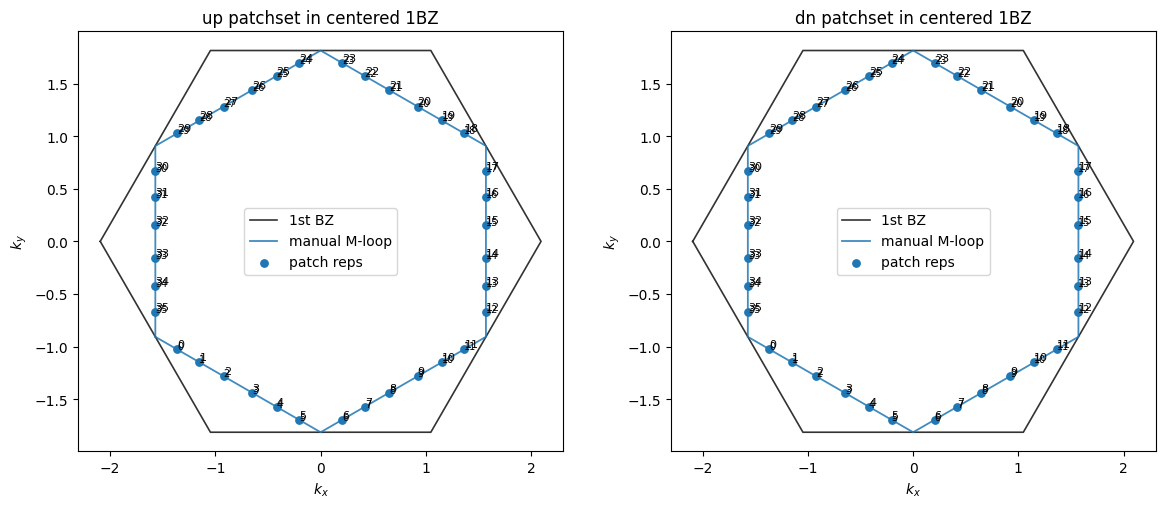

In [15]:
UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)
LOCAL_BAND_INDEX = 1
model = noninteracting.KagomeKaneMeleSOC(dict(t=1.0, l1=0.2,l2=0), spin=True, B=None)

# ------------------------------------------------------------
# choose patch density / options here
# ------------------------------------------------------------
POINTS_PER_EDGE = 7
GAUGE_FIX = True
CLOSE_LOOP_GAUGE = True
GAUGE_ANCHOR = "max_component"  # or "first_component"


# ============================================================
# build the final default patchsets for the whole pipeline
# ============================================================
PATCHSETS = build_tr_adapted_patchsets(
    model,
    UP_SLICE,
    DN_SLICE,
    LOCAL_BAND_INDEX,
)

# optional sanity check
defect = pp_triplet_gauge_defect(PATCHSETS)
print("pairing gauge defect max =", np.max(np.abs(defect)))
print("pairing gauge defect fro =", np.linalg.norm(defect))

# ------------------------------------------------------------
# basic sanity: centered 1BZ patch plots
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, spin in zip(axes, ["up", "dn"]):
    patching.plot_patchset(
        PATCHSETS[spin],
        ax=ax,
        show_contour=True,
        show_velocity=False,
        show_bz=True,
    )

    ks = np.array([p.k_cart for p in PATCHSETS[spin].patches], dtype=float)
    for i, k in enumerate(ks):
        ax.text(k[0], k[1], str(i), fontsize=8, ha="left", va="bottom")

    ax.set_title(f"{spin} patchset in centered 1BZ")

plt.tight_layout()
plt.show()

# Model

CASE = U_only  | U = 4.0  V = 0
T_START, T_STOP, NFREQ, NSTEPS = 5.0 0.05 50 600
NPATCH = 36
diagnosis_Qs:
  Q0 = (0.000000, 0.000000)
  Q1 = (-1.570796, -0.906900)
  Q2 = (0.000000, -1.813799)
  Q3 = (-1.570796, 0.906900)

solver built.
temperature path length = 600
initial channel norm    = 3.681629423493432
solver.patch_measure_mode = length_over_vf_soft

=== bare (initial) sign-aware kernel metrics ===


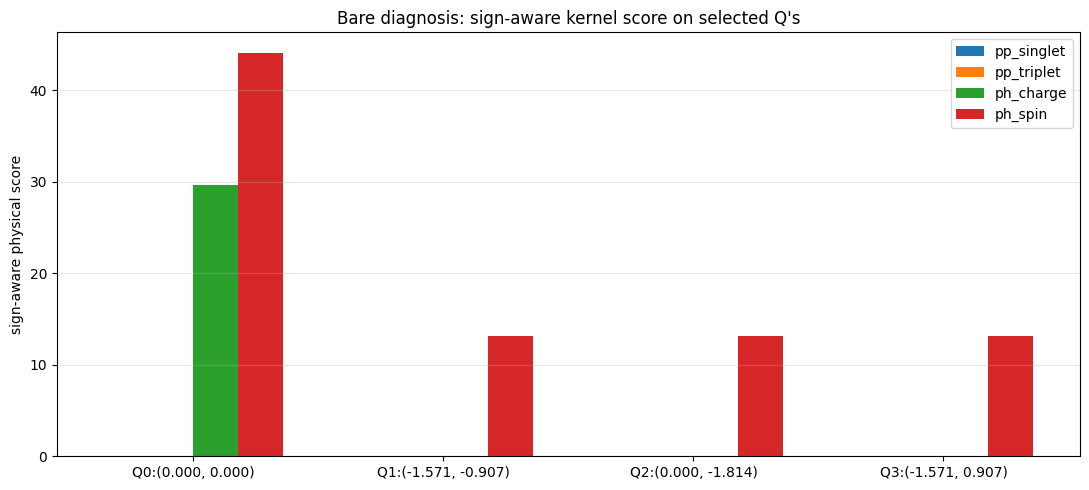


=== bare (initial) physical instability metrics ===


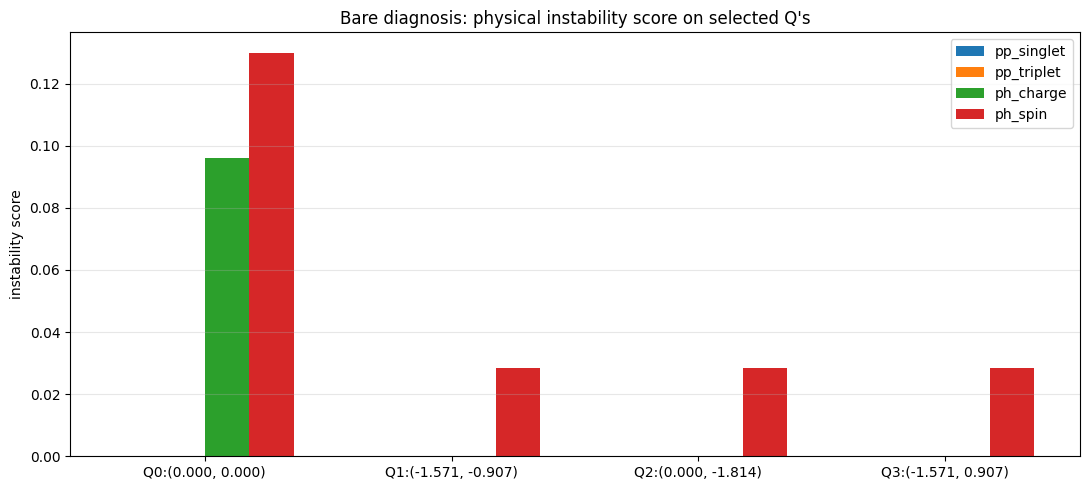

In [17]:
# ============================================================
# Choose interaction case
# ============================================================
CASE = "U_only"   # "U_only" or "V_only"

if CASE == "U_only":
    U_TEST, V_TEST = 4., 0
# elif CASE == "V_only":
#     U_TEST, V_TEST = 0.0, 10.0
else:
    raise ValueError("CASE must be 'U_only' or 'V_only'")


# ============================================================
# Basic diagnosis setup
# ============================================================
T_START = 5.0
T_STOP  = 0.05
NFREQ   = 50
NSTEPS  = 600

# Selected transfer momenta
M6 = patching.exact_M6_points_1bz(model)
diagnosis_Qs = [
    np.array([0.0, 0.0]),
    np.array(M6[0], dtype=float),
    np.array(M6[1], dtype=float),
    np.array(M6[-1], dtype=float),
]

print("CASE =", CASE, " | U =", U_TEST, " V =", V_TEST)
print("T_START, T_STOP, NFREQ, NSTEPS =", T_START, T_STOP, NFREQ, NSTEPS)
print("NPATCH =", PATCHSETS["up"].Npatch)
print("diagnosis_Qs:")
for i, q in enumerate(diagnosis_Qs):
    print(f"  Q{i} = {fmt_q(q, nd=6)}")


# ============================================================
# Build bare interaction + bare solver
# ============================================================
bare_int = interaction.BareExtendedHubbard.from_kagome_model(model, U=U_TEST, V=V_TEST)
bare_sz0 = frg_flow.BareSZ0VertexFromInteraction(bare_int, PATCHSETS)

solver = frg_flow.FRGFlowSolverSZ0(
    patchsets=PATCHSETS,
    bare_vertex=bare_sz0,

    T_start=T_START,
    T_stop=T_STOP,
    n_steps=NSTEPS,
    temperature_grid="linear",
    nfreq=NFREQ,
    include_explicit_T_prefactor=True,

    # lenient integrator setup for exploration
    max_relative_update=5.0,
    min_substep_fraction=1.0 ,
    channel_divergence_threshold=1e12,

    diagnosis_Qs=diagnosis_Qs,
    diagnosis_score_threshold=None,
    diagnosis_landau_F=False,

    # current flow measure
    patch_measure_mode="length_over_vf_soft",              # change here later if needed
    patch_measure_soft_vf_eps=1e-8,
    patch_measure_normalize_mean=False,
)

print("\nsolver built.")
print("temperature path length =", len(solver.temperature_path))
print("initial channel norm    =", solver.state.channel_norm())
print("solver.patch_measure_mode =", getattr(solver, "patch_measure_mode", None))

# ============================================================
# Bare sign-aware kernel metrics
# ============================================================
builder0 = build_builder_from_solver(solver, Landau_F=False)
df_signaware_bare, signaware_store = evaluate_signaware_selected_Qs(
    builder0,
    diagnosis_Qs,
    landau_F=False,
)

print("\n=== bare (initial) sign-aware kernel metrics ===")
# display(df_signaware_bare.sort_values(["Q_index", "channel"]).reset_index(drop=True))

plot_channel_bars(
    df_signaware_bare,
    value_col="physical_score",
    title="Bare diagnosis: sign-aware kernel score on selected Q's",
    ylabel="sign-aware physical score",
)

best_signaware_bare = leading_row_from_df(df_signaware_bare, "physical_score")
# print("\n=== bare sign-aware leader ===")
# print("channel :", best_signaware_bare["channel"])
# print("Q       :", fmt_q(best_signaware_bare["Q"], nd=6))
# print("score   :", f"{best_signaware_bare['physical_score']:.12e}")
# print("chosen  :", best_signaware_bare["chosen_sign"], f"{best_signaware_bare['chosen_eval']:.12e}")


# ============================================================
# Bare physical instability diagnosis
# ============================================================
df_instab_bare, instab_store = evaluate_instability_selected_Qs(
    builder0,
    solver,
    diagnosis_Qs,
    temperature=T_START,          # use initial T
    landau_F=False,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
)

print("\n=== bare (initial) physical instability metrics ===")
# display(df_instab_bare.sort_values(["Q_index", "channel"]).reset_index(drop=True))

plot_channel_bars(
    df_instab_bare,
    value_col="score",
    title="Bare diagnosis: physical instability score on selected Q's",
    ylabel="instability score",
)

best_instab_bare = leading_row_from_df(df_instab_bare, "score")
# print("\n=== bare physical-instability leader ===")
# print("channel :", best_instab_bare["channel"])
# print("Q       :", fmt_q(best_instab_bare["Q"], nd=6))
# print("score   :", f"{best_instab_bare['score']:.12e}")
# print("eval    :", f"{best_instab_bare['leading_eval']:.12e}")
# print("bubble  :", best_instab_bare["bubble_source"])
# print("proj    :", best_instab_bare["projection_name"])

# Flow


================ RG FLOW START ================

step=   0 | T=5.000000 | rhs_norm=0.000e+00 | lead_kernel=ph_spin @ Q0:(0.000, 0.000) score=4.412e+01
kernel scores: pp_singlet=2.245e-14, pp_triplet=4.916e-15, ph_charge=2.969e+01, ph_spin=4.412e+01
    lead_instability=ph_spin @ Q0:(0.000, 0.000) score=1.300e-01
instability: pp_singlet=7.275e-17, pp_triplet=1.394e-17, ph_charge=9.609e-02, ph_spin=1.300e-01
step=   5 | T=4.958681 | rhs_norm=1.209e+00 | lead_kernel=ph_spin @ Q0:(0.000, 0.000) score=4.376e+01
kernel scores: pp_singlet=1.713e-01, pp_triplet=5.592e-02, ph_charge=2.942e+01, ph_spin=4.376e+01
    lead_instability=ph_spin @ Q0:(0.000, 0.000) score=1.312e-01
instability: pp_singlet=7.763e-04, pp_triplet=2.737e-04, ph_charge=9.691e-02, ph_spin=1.312e-01
step=  10 | T=4.917362 | rhs_norm=1.211e+00 | lead_kernel=ph_spin @ Q0:(0.000, 0.000) score=4.340e+01
kernel scores: pp_singlet=3.440e-01, pp_triplet=1.113e-01, ph_charge=2.915e+01, ph_spin=4.340e+01
    lead_instability=ph_spin

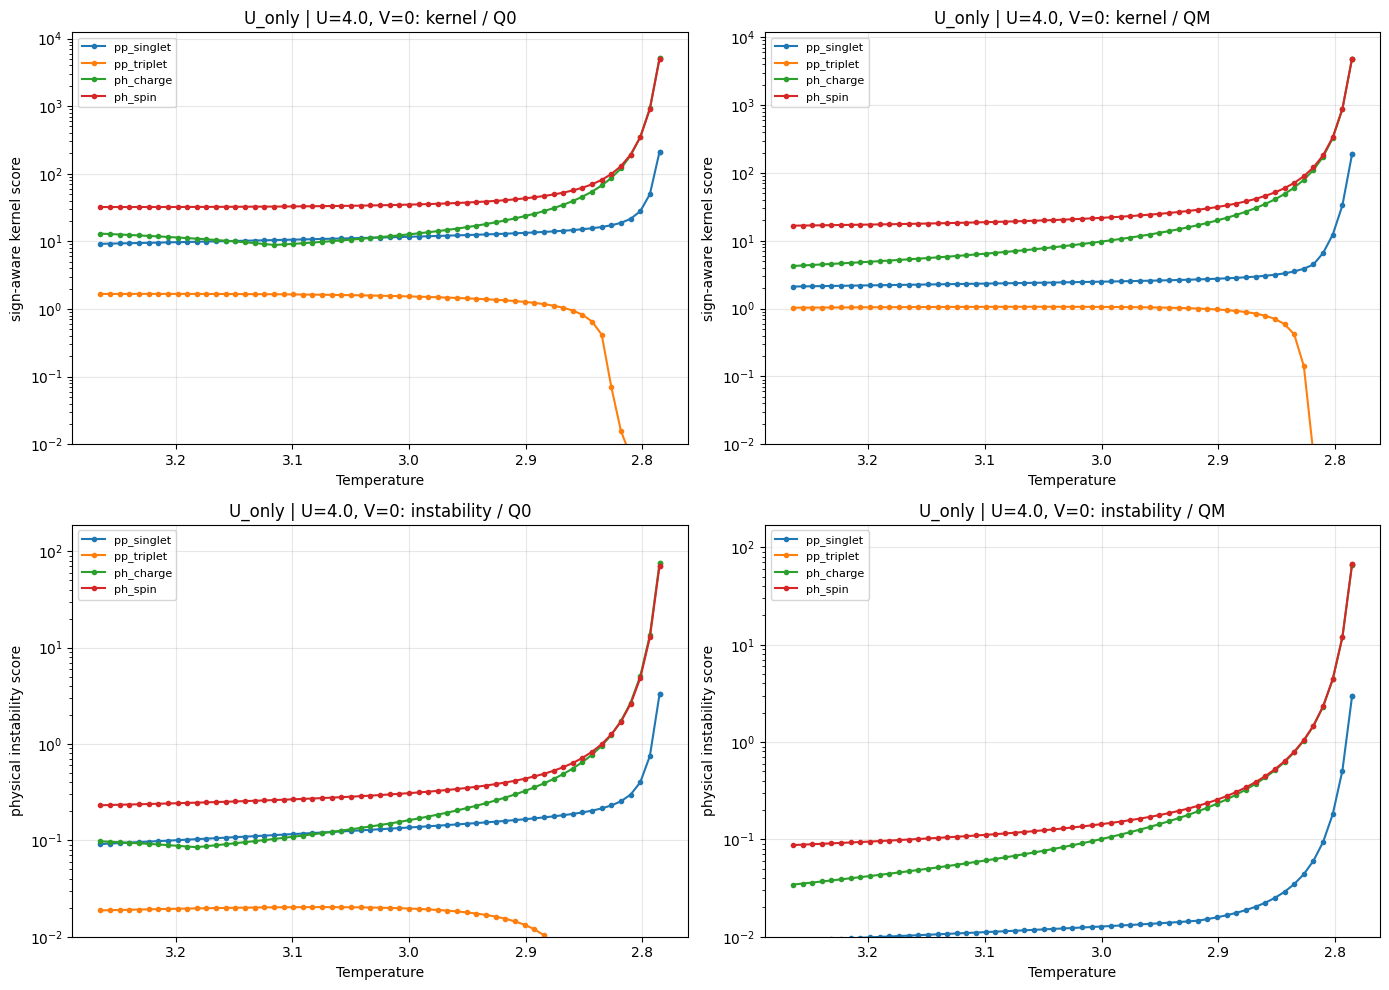

In [19]:
# ============================================================
# Flow run parameters
# ============================================================
PRINT_EVERY = 5               # print every N steps
LAST_N_STEPS_TO_PLOT = 60     # None -> plot all; integer -> only last N steps
PLOT_YLOG = True

# physical instability diagnosis options
PH_BUBBLE_MODE = "patchrep"
PROJECT_PH_CHARGE_Q0_UNIFORM = True
PROJECT_PP_SINGLET_Q0_LOCAL_GRAM_DEFAULT = False


print("\n================ RG FLOW START ================\n")

# history, signaware_history_df, instability_history_df, grouped_plot_df = run_flow_with_tracking(
#     solver,
#     diagnosis_Qs,
#     print_every=PRINT_EVERY,
#     ph_bubble_mode=PH_BUBBLE_MODE,
#     project_ph_charge_q0_uniform=PROJECT_PH_CHARGE_Q0_UNIFORM,
#     project_pp_singlet_q0_local_gram_default=PROJECT_PP_SINGLET_Q0_LOCAL_GRAM_DEFAULT,
# )
history, signaware_history_df, instability_history_df, grouped_plot_df, snapshots = run_flow_with_tracking_and_snapshots(
    solver,
    diagnosis_Qs,
    print_every=PRINT_EVERY,
    ph_bubble_mode=PH_BUBBLE_MODE,
    project_ph_charge_q0_uniform=PROJECT_PH_CHARGE_Q0_UNIFORM,
    project_pp_singlet_q0_local_gram_default=PROJECT_PP_SINGLET_Q0_LOCAL_GRAM_DEFAULT,
)

print("\n================ RG FLOW DONE ================\n")
print("history length =", len(history))

last_rec = history[-1]
print("final step =", last_rec.step_index)
print("final T    =", last_rec.temperature)
print("final rhs_norm =", last_rec.rhs_norm)
print("final channel_norm =", last_rec.channel_norm)
print("instability =", last_rec.instability)
print("terminated_early =", last_rec.terminated_early)
print("instability_reason =", last_rec.instability_reason)
print("termination_reason =", last_rec.termination_reason)

# display(signaware_history_df.tail(12))
# display(instability_history_df.tail(12))

plot_flow_group_curves(
    grouped_plot_df,
    last_n_steps=LAST_N_STEPS_TO_PLOT,
    ylog=PLOT_YLOG,
    title_prefix=f"{CASE} | U={U_TEST}, V={V_TEST}",
    ylim=1e-2
)

# Diagnosis

## Instability

Diagnosing step_index = 265
T = 2.810100
rhs_norm = 7.970e+03
channel_norm = 1.865e+02
instability = False
terminated_early = False
instability_reason = None
termination_reason = None

=== sign-aware leader at selected step ===
channel : ph_spin
Q       : (0.000000, 0.000000)
score   : 1.918228243309e+02
chosen  : negative -1.918228243309e+02

=== physical-instability leader at selected step ===
channel : ph_charge
Q       : (0.000000, 0.000000)
score   : 2.690808514946e+00
eval    : 2.690808514946e+00
bubble  : patchrep:bubble_dot_ph(eps_p,eps_p+Q)*measure_p
proj    : nan


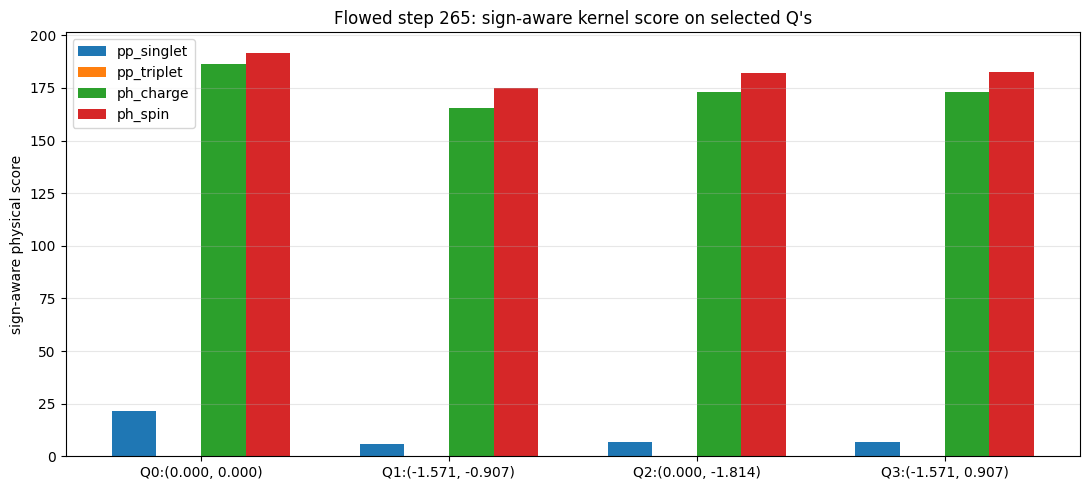

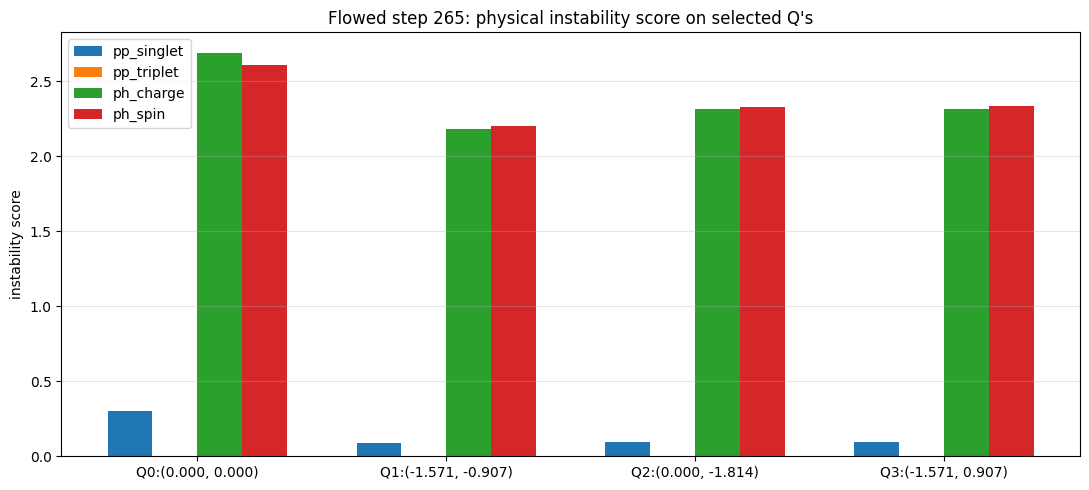

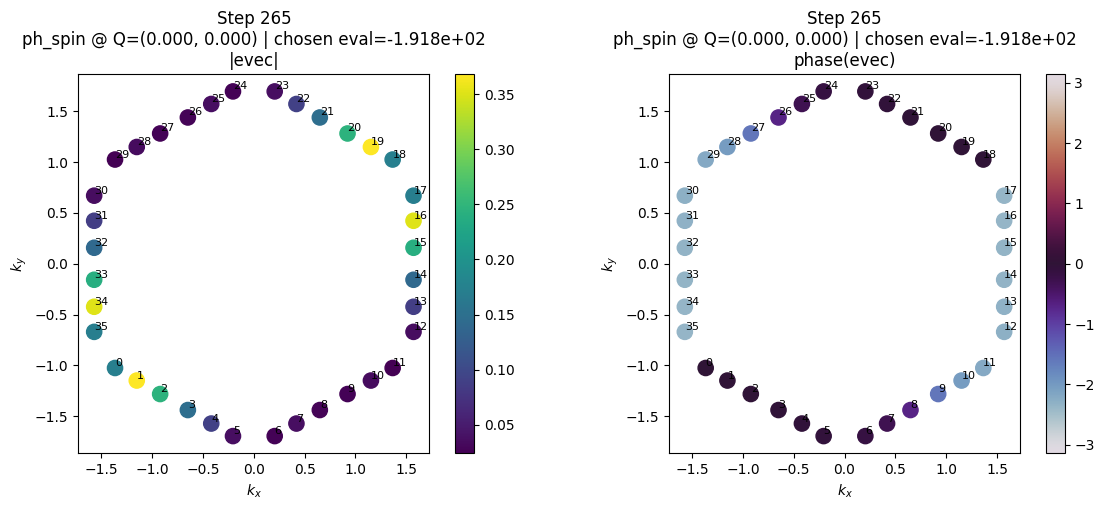

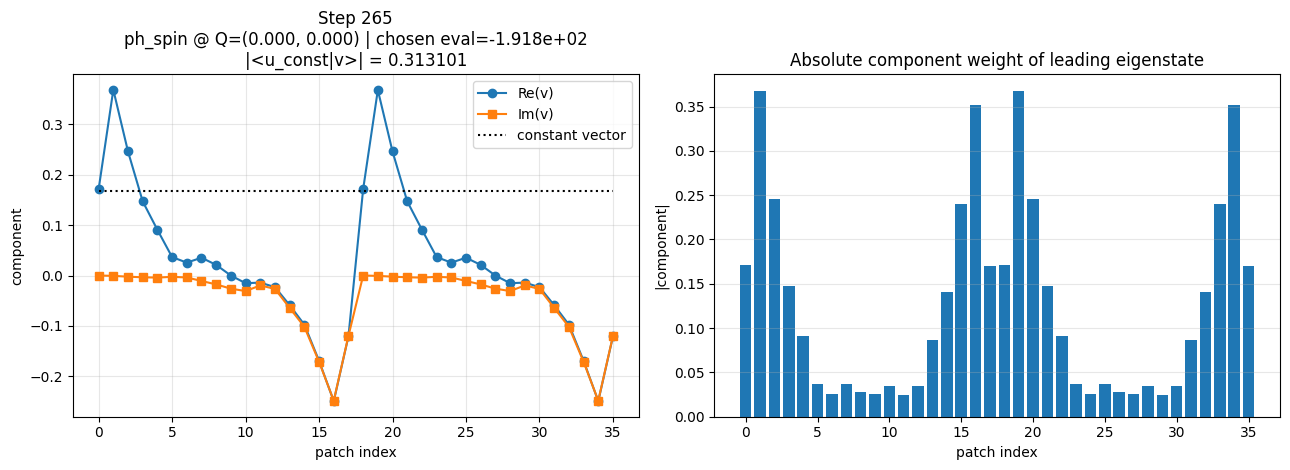


=== leader eigenstate summary ===
channel            : ph_spin
Q                  : (0.000000, 0.000000)
selected eigenvalue: -1.918228243309e+02
kernel dimension   : 36
|<u_const|v>|      : 3.131005376271e-01


In [36]:
# ============================================================
# Diagnose one flowed step
# ============================================================
STEP_SELECTOR = -5  # -1 last step, -2 second last, -3 third last, or exact step index

diagnosis_result = diagnose_flowed_step(
    solver,
    history,
    diagnosis_Qs,
    step_selector=STEP_SELECTOR,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    plot_eigenstate=True,
)
# Optional: inspect the raw tables
# display(diagnosis_result["df_signaware"].sort_values(["Q_index", "channel"]).reset_index(drop=True))
# display(diagnosis_result["df_instability"].sort_values(["Q_index", "channel"]).reset_index(drop=True))

## particle-hole

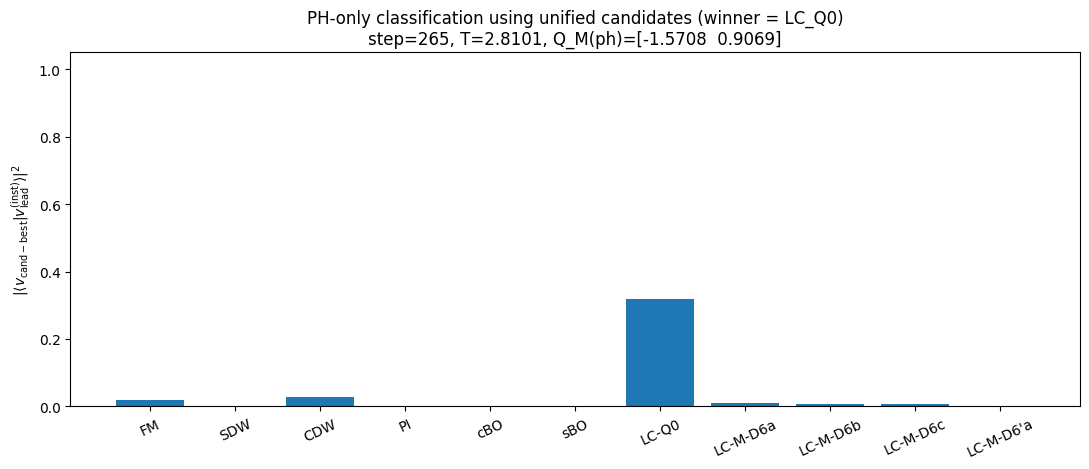

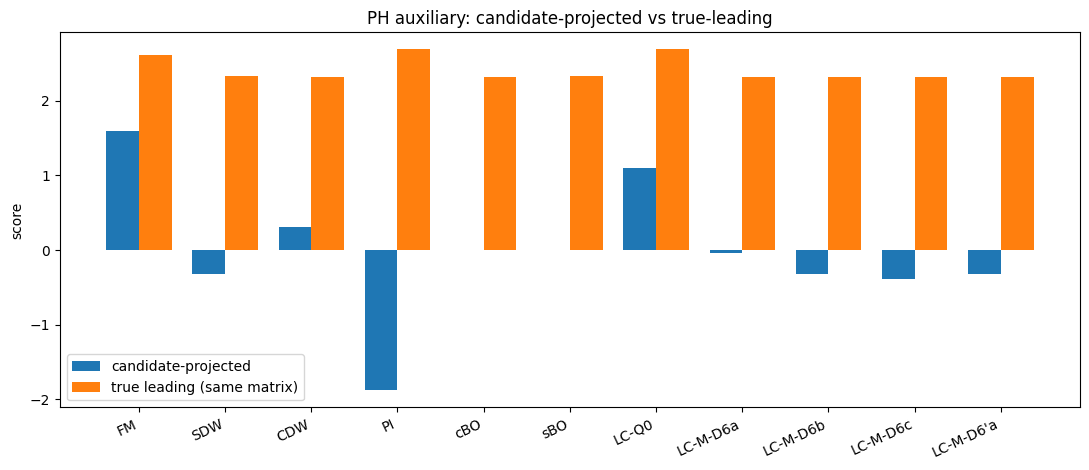

In [49]:
# ============================================================
# PH-only classification using unified candidates
# ============================================================
USE_BUBBLE_DRESSED_OPERATOR = True
Landau_F_FOR_CHANNEL_BUILD = False
STEP_SELECTOR = -5

INCLUDE_PH_CURRENT = True
USE_EXACT_Q0_NAGAOSA_FOR_PIPELINE = False

selected_rec, selected_snap = _resolve_snapshot_and_record(
    history,
    snapshots,
    STEP_SELECTOR,
)

# -------------------------------
# Resolve Qs
# -------------------------------
if "diagnosis_Qs" in globals() and diagnosis_Qs is not None:
    diag_Qs = [np.asarray(q, dtype=float) for q in diagnosis_Qs]
else:
    diag_Qs = [np.asarray(q, dtype=float) for q in solver.diagnosis_Qs]

Q0_list = [q for q in diag_Qs if _allclose_zero(q)]
QM_list = [q for q in diag_Qs if not _allclose_zero(q)]

if len(Q0_list) != 1:
    raise ValueError(f"Expected exactly one Q=0, found {len(Q0_list)}")
if len(QM_list) == 0:
    raise ValueError("Need at least one finite-Q in diagnosis_Qs.")

Q0 = np.asarray(Q0_list[0], dtype=float)

# -------------------------------
# Config / selected finite Q
# -------------------------------
instability_cfg = _default_instability_config_from_solver(solver)
band_index_here = _solver_band_index(solver)

Q_M_ph = _choose_best_QM_for_ph(
    solver,
    QM_list,
    instability_cfg,
    snapshot=selected_snap,
    Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
)

# -------------------------------
# Candidate list
# -------------------------------
candidate_specs_ph = [
    ("FM",         Q0,     "ph_spin",   "ph_real",    ["FM_Q0"],        "FM"),
    ("SDW",        Q_M_ph, "ph_spin",   "ph_real",    ["SDW_M"],        "SDW"),
    ("CDW",        Q_M_ph, "ph_charge", "ph_real",    ["CDW_M"],        "CDW"),
    ("PI",         Q0,     "ph_charge", "ph_real",    ["PI_Q0_E2"],     "PI"),
    ("cBO",        Q_M_ph, "ph_charge", "ph_real",    ["CBO_M"],        "cBO"),
    ("sBO",        Q_M_ph, "ph_spin",   "ph_real",    ["SBO_M"],        "sBO"),
]

if INCLUDE_PH_CURRENT:
    candidate_specs_ph += [
        ("LC-Q0",     Q0,     "ph_charge", "ph_current", ["LC_Q0_NAGAOSA", "LC_Q0_FLOWA"], "LC_Q0"),
        ("LC-M-D6a",  Q_M_ph, "ph_charge", "ph_current", ["LC_M_D6A"],  "LC_M_D6A"),
        ("LC-M-D6b",  Q_M_ph, "ph_charge", "ph_current", ["LC_M_D6B"],  "LC_M_D6B"),
        ("LC-M-D6c",  Q_M_ph, "ph_charge", "ph_current", ["LC_M_D6C"],  "LC_M_D6C"),
        ("LC-M-D6'a", Q_M_ph, "ph_charge", "ph_current", ["LC_M_D6PA"], "LC_M_D6PA"),
    ]

# -------------------------------
# Evaluate
# -------------------------------
rows_ph = []
packs = {}

for label, Q_use, kernel_name, candidate_kind, families, final_label in candidate_specs_ph:
    pack = _evaluate_unified_candidate_family_dual_overlap(
        solver,
        Q_use,
        kernel_name,
        candidate_kind=candidate_kind,
        families=families,
        instability_cfg=instability_cfg,
        snapshot=selected_snap,
        use_operator=USE_BUBBLE_DRESSED_OPERATOR,
        Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
        m_index=None,
        band_index=band_index_here,
        use_exact_q0_nagaosa=USE_EXACT_Q0_NAGAOSA_FOR_PIPELINE,
    )

    packs[label] = pack

    rows_ph.append({
        "label": label,
        "final_label": final_label,
        "candidate_kind": candidate_kind,
        "families": ",".join(families),
        "Q_used": np.array2string(np.asarray(Q_use), precision=6),
        "kernel_name": kernel_name,
        "projected_score": float(pack["projected_score"]),
        "analysis_true_leading_score": float(pack["analysis_true_leading_score"]),
        "kernel_true_leading_score": float(pack["kernel_true_leading_score"]),
        "overlap_with_instability_leader": float(pack["overlap_with_instability_leader"]),
        "overlap_with_analysis_leader": float(pack["overlap_with_analysis_leader"]),
        "overlap_with_kernel_leader": float(pack["overlap_with_kernel_leader"]),
        "member_overlaps_to_candidate_best": pack["candidate_member_overlaps"],
    })

df_ph = pd.DataFrame(rows_ph)
winner_idx = int(np.argmax(df_ph["overlap_with_instability_leader"].to_numpy(float)))
winner_row = df_ph.iloc[winner_idx]

# display(df_ph)

# -------------------------------
# Plot 1: main overlap classification
# -------------------------------
labels = df_ph["label"].tolist()
overlaps = df_ph["overlap_with_instability_leader"].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(11.0, 4.8))
ax.bar(labels, overlaps)
ax.set_ylim(0, 1.05)
ax.set_ylabel(r"$|\langle v_{\rm cand-best}|v_{\rm lead}^{(\rm inst)}\rangle|^2$")
ax.set_title(
    f"PH-only classification using unified candidates "
    f"(winner = {winner_row['final_label']})\n"
    f"step={int(selected_rec.step_index)}, T={selected_snap.T:.6g}, "
    f"Q_M(ph)={np.array2string(Q_M_ph, precision=4)}"
)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

# -------------------------------
# Plot 2: projected score vs true leading score
# -------------------------------
projected_scores = df_ph["projected_score"].to_numpy(dtype=float)
true_scores = df_ph["analysis_true_leading_score"].to_numpy(dtype=float)

x = np.arange(len(labels))
w = 0.38

fig, ax = plt.subplots(figsize=(11.0, 4.8))
ax.bar(x - w/2, projected_scores, width=w, label="candidate-projected")
ax.bar(x + w/2, true_scores, width=w, label="true leading (same matrix)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("score")
ax.set_title("PH auxiliary: candidate-projected vs true-leading")
ax.legend()
plt.tight_layout()
plt.show()

## Particle-Particle

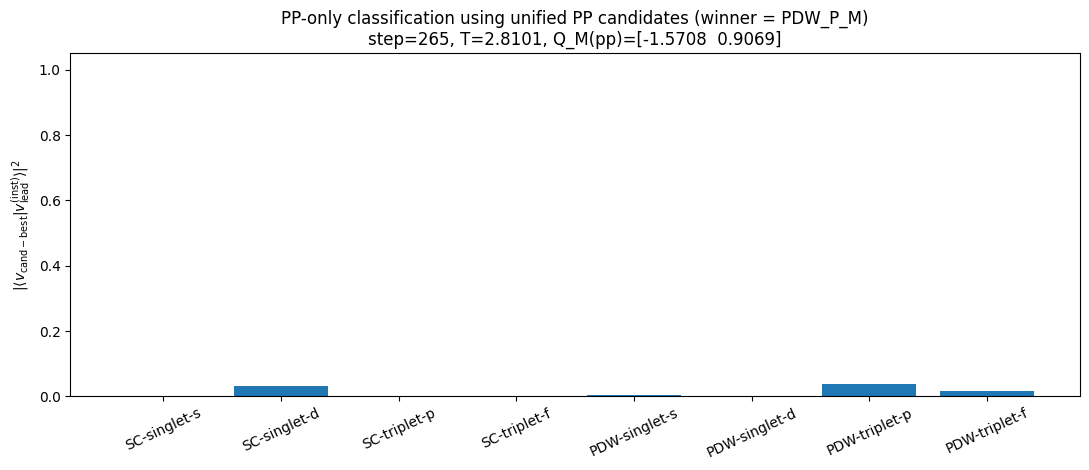

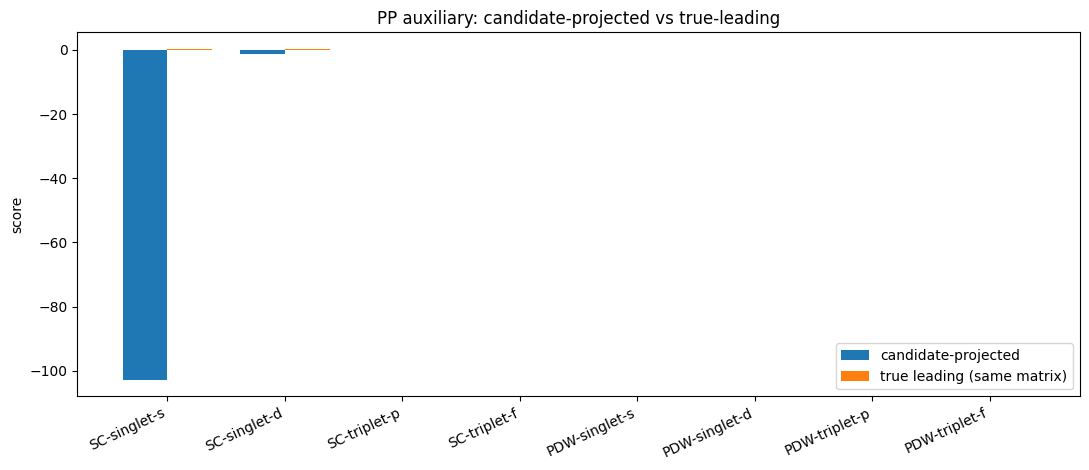

In [51]:
# ============================================================
# PP-only classification using unified PP-real candidates
#   Uses all 8 PP families:
#     Q0:  S, D, P, F
#     Q=M: PDW_S, PDW_D, PDW_P, PDW_F
# ============================================================
USE_BUBBLE_DRESSED_OPERATOR = True
Landau_F_FOR_CHANNEL_BUILD = False
STEP_SELECTOR = -5

selected_rec, selected_snap = _resolve_snapshot_and_record(
    history,
    snapshots,
    STEP_SELECTOR,
)

# -------------------------------
# Resolve Qs
# -------------------------------
if "diagnosis_Qs" in globals() and diagnosis_Qs is not None:
    diag_Qs = [np.asarray(q, dtype=float) for q in diagnosis_Qs]
else:
    diag_Qs = [np.asarray(q, dtype=float) for q in solver.diagnosis_Qs]

Q0_list = [q for q in diag_Qs if _allclose_zero(q)]
QM_list = [q for q in diag_Qs if not _allclose_zero(q)]

if len(Q0_list) != 1:
    raise ValueError(f"Expected exactly one Q=0, found {len(Q0_list)}")
if len(QM_list) == 0:
    raise ValueError("Need at least one finite-Q in diagnosis_Qs.")

Q0 = np.asarray(Q0_list[0], dtype=float)

# -------------------------------
# Config / selected finite Q
# -------------------------------
instability_cfg = _default_instability_config_from_solver(solver)
band_index_here = _solver_band_index(solver)

Q_M_pp = _choose_best_QM_for_pp(
    solver,
    QM_list,
    instability_cfg,
    snapshot=selected_snap,
    Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
)

# -------------------------------
# 8 PP candidate families from candidate file
# -------------------------------
candidate_specs_pp = [
    ("SC-singlet-s",   Q0,     "pp_singlet", "pp_real", ["PP_S_Q0"],  "PP_S_Q0"),
    ("SC-singlet-d",   Q0,     "pp_singlet", "pp_real", ["PP_D_Q0"],  "PP_D_Q0"),
    ("SC-triplet-p",   Q0,     "pp_triplet", "pp_real", ["PP_P_Q0"],  "PP_P_Q0"),
    ("SC-triplet-f",   Q0,     "pp_triplet", "pp_real", ["PP_F_Q0"],  "PP_F_Q0"),

    ("PDW-singlet-s",  Q_M_pp, "pp_singlet", "pp_real", ["PDW_S_M"],  "PDW_S_M"),
    ("PDW-singlet-d",  Q_M_pp, "pp_singlet", "pp_real", ["PDW_D_M"],  "PDW_D_M"),
    ("PDW-triplet-p",  Q_M_pp, "pp_triplet", "pp_real", ["PDW_P_M"],  "PDW_P_M"),
    ("PDW-triplet-f",  Q_M_pp, "pp_triplet", "pp_real", ["PDW_F_M"],  "PDW_F_M"),
]

# -------------------------------
# Evaluate
# -------------------------------
rows_pp = []
packs_pp = {}

for label, Q_use, kernel_name, candidate_kind, families, final_label in candidate_specs_pp:
    pack = _evaluate_unified_candidate_family_dual_overlap(
        solver,
        Q_use,
        kernel_name,
        candidate_kind=candidate_kind,
        families=families,
        instability_cfg=instability_cfg,
        snapshot=selected_snap,
        use_operator=USE_BUBBLE_DRESSED_OPERATOR,
        Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
        m_index=None,
        band_index=band_index_here,
        use_exact_q0_nagaosa=False,
    )

    packs_pp[label] = pack

    rows_pp.append({
        "label": label,
        "final_label": final_label,
        "families": ",".join(families),
        "Q_used": np.array2string(np.asarray(Q_use), precision=6),
        "kernel_name": kernel_name,
        "projected_score": float(pack["projected_score"]),
        "analysis_true_leading_score": float(pack["analysis_true_leading_score"]),
        "kernel_true_leading_score": float(pack["kernel_true_leading_score"]),
        "overlap_with_instability_leader": float(pack["overlap_with_instability_leader"]),
        "overlap_with_analysis_leader": float(pack["overlap_with_analysis_leader"]),
        "overlap_with_kernel_leader": float(pack["overlap_with_kernel_leader"]),
        "member_overlaps_to_candidate_best": pack["candidate_member_overlaps"],
    })

df_pp = pd.DataFrame(rows_pp)
winner_idx = int(np.argmax(df_pp["overlap_with_instability_leader"].to_numpy(float)))
winner_row = df_pp.iloc[winner_idx]

# display(df_pp)

# -------------------------------
# Plot 1: main overlap classification
# -------------------------------
labels = df_pp["label"].tolist()
overlaps = df_pp["overlap_with_instability_leader"].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(11.0, 4.8))
ax.bar(labels, overlaps)
ax.set_ylim(0, 1.05)
ax.set_ylabel(r"$|\langle v_{\rm cand-best}|v_{\rm lead}^{(\rm inst)}\rangle|^2$")
ax.set_title(
    f"PP-only classification using unified PP candidates "
    f"(winner = {winner_row['final_label']})\n"
    f"step={int(selected_rec.step_index)}, T={selected_snap.T:.6g}, "
    f"Q_M(pp)={np.array2string(Q_M_pp, precision=4)}"
)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

# -------------------------------
# Plot 2: projected score vs true leading score
# -------------------------------
projected_scores = df_pp["projected_score"].to_numpy(dtype=float)
true_scores = df_pp["analysis_true_leading_score"].to_numpy(dtype=float)

x = np.arange(len(labels))
w = 0.38

fig, ax = plt.subplots(figsize=(11.0, 4.8))
ax.bar(x - w/2, projected_scores, width=w, label="candidate-projected")
ax.bar(x + w/2, true_scores, width=w, label="true leading (same matrix)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("score")
ax.set_title("PP auxiliary: candidate-projected vs true-leading")
ax.legend()
plt.tight_layout()
plt.show()

### dim-2 Leading Subspace

,step_index,T,label,dim
0,265,2.8101,ph_charge @ Q0,1
1,265,2.8101,ph_charge @ QM,1
2,265,2.8101,ph_spin @ Q0,2
3,265,2.8101,ph_spin @ QM,4
4,265,2.8101,pp_singlet @ Q0,1
5,265,2.8101,pp_singlet @ QM,1
6,265,2.8101,pp_triplet @ Q0,6
7,265,2.8101,pp_triplet @ QM,6


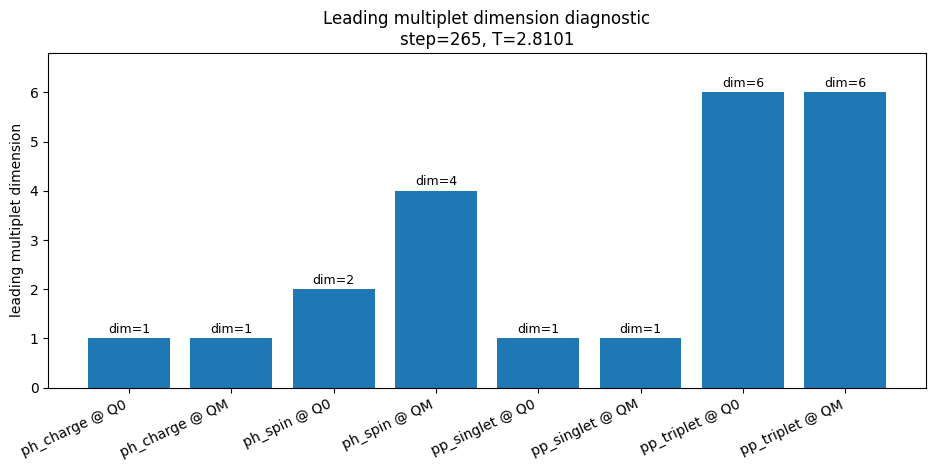

,step_index,T,label,channel,candidate_rank,leading_dim,score
0,265,2.8101,FM,ph_spin @ Q0,1,2,1.599635


In [56]:
# ============================================================
# Leading multiplet / degeneracy diagnostic
# Candidate-based version, no harmonic templates
# ============================================================

LAST_N_STEPS = 1
STEP_SELECTOR = -5
USE_BUBBLE_DRESSED_OPERATOR = True
Landau_F_FOR_CHANNEL_BUILD = False

selected_rec, selected_snap = cand_ts_resolve_record_snapshot(
    history,
    snapshots,
    history[STEP_SELECTOR].step_index if STEP_SELECTOR < 0 else STEP_SELECTOR,
)

if "diagnosis_Qs" in globals() and diagnosis_Qs is not None:
    diag_Qs = [np.asarray(q, dtype=float) for q in diagnosis_Qs]
else:
    diag_Qs = [np.asarray(q, dtype=float) for q in solver.diagnosis_Qs]

(
    df_kernel_one,
    df_candidate_one,
    df_dim_one,
    df_dim_candidate_one,
    df_meta_one,
) = collect_order_timeseries_candidate_based_clean(
    solver,
    history,
    snapshots,
    diagnosis_Qs=diag_Qs,
    last_n_steps=abs(STEP_SELECTOR) if STEP_SELECTOR < 0 else 1,
    USE_BUBBLE_DRESSED_OPERATOR=USE_BUBBLE_DRESSED_OPERATOR,
    Landau_F_FOR_CHANNEL_BUILD=Landau_F_FOR_CHANNEL_BUILD,
)

target_step = int(selected_rec.step_index)

df_dim_show = df_dim_one[df_dim_one["step_index"] == target_step].copy()
display(df_dim_show)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
labels = df_dim_show["label"].tolist()
dims = df_dim_show["dim"].to_numpy(dtype=int)
x = np.arange(len(labels))

ax.bar(x, dims)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("leading multiplet dimension")
ax.set_title(
    "Leading multiplet dimension diagnostic\n"
    f"step={target_step}, T={float(selected_snap.T):.6g}"
)

for i, dim in enumerate(dims):
    ax.text(i, dim + 0.05, f"dim={dim}", ha="center", va="bottom", fontsize=9)

ax.set_ylim(0, max(2.5, np.max(dims) + 0.8))
plt.tight_layout()
plt.show()

df_dim2 = df_dim_candidate_one[
    (df_dim_candidate_one["step_index"] == target_step)
    & (df_dim_candidate_one["leading_dim"] == 2)
].copy()

display(df_dim2.sort_values(["channel", "score"], ascending=[True, False]))

## Time-Serie

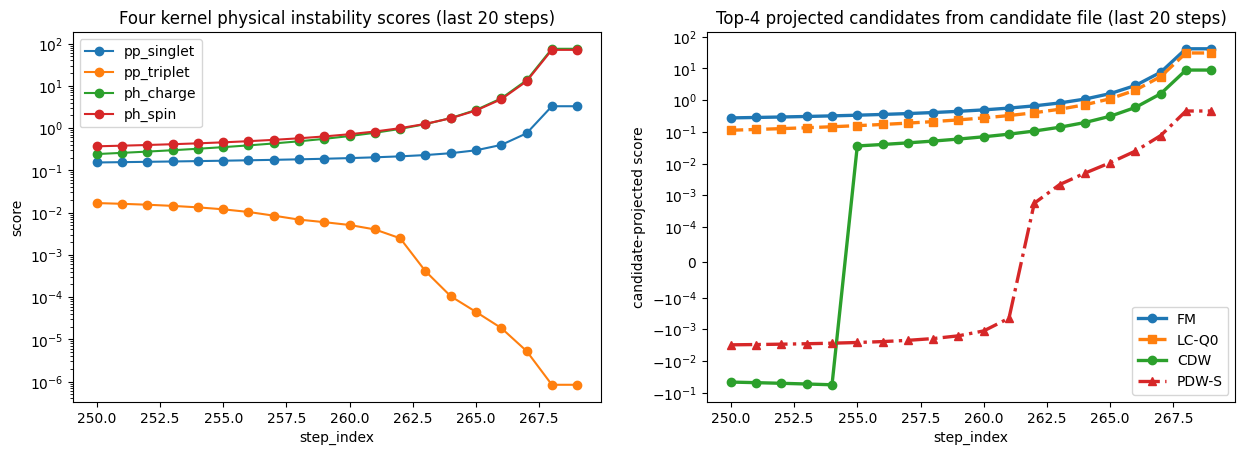

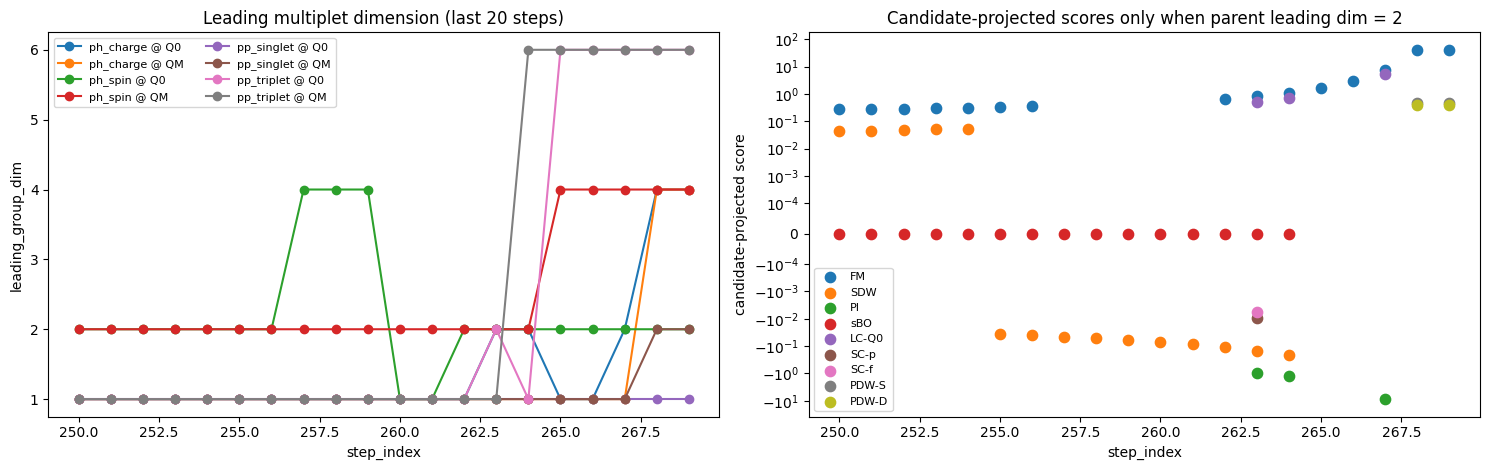

In [58]:
# ============================================================
# Last-N-step line plots: clean candidate-based version
# ============================================================
LAST_N_STEPS = 20
USE_BUBBLE_DRESSED_OPERATOR = True
Landau_F_FOR_CHANNEL_BUILD = False
X_AXIS = "step_index"   # or "T"

if "diagnosis_Qs" in globals() and diagnosis_Qs is not None:
    diag_Qs = [np.asarray(q, dtype=float) for q in diagnosis_Qs]
else:
    diag_Qs = [np.asarray(q, dtype=float) for q in solver.diagnosis_Qs]

(
    df_kernel_scores_ts,
    df_candidate_scores_ts,
    df_dim_ts,
    df_dim_candidate_scores_ts,
    df_meta_ts,
) = collect_order_timeseries_candidate_based_clean(
    solver,
    history,
    snapshots,
    diagnosis_Qs=diag_Qs,
    last_n_steps=LAST_N_STEPS,
    USE_BUBBLE_DRESSED_OPERATOR=USE_BUBBLE_DRESSED_OPERATOR,
    Landau_F_FOR_CHANNEL_BUILD=Landau_F_FOR_CHANNEL_BUILD,
)

plot_order_timeseries_candidate_based_clean(
    df_kernel_scores_ts,
    df_candidate_scores_ts,
    df_dim_ts,
    df_dim_candidate_scores_ts,
    x_axis=X_AXIS,
    title_suffix=f" (last {LAST_N_STEPS} steps)",
    top_k=4,
    force_top_labels=("FM", "LC-Q0", "CDW"),
)

# display(df_meta_ts.tail())

# display(
#     df_candidate_scores_ts[
#         df_candidate_scores_ts["label"].isin(["FM", "LC-Q0", "CDW", "PDW-S"])
#     ].pivot(index="step_index", columns="label", values="score").tail(LAST_N_STEPS)
# )

# Debug

In [ ]:
# ============================================================
# Setup for irrep-2 vs gauge-artifact tests
# Uses low-level module API directly, not notebook wrappers.
# ============================================================
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import channels as chmod
import instability as inst
import frg_flow as flowmod
import patching as patchmod


# -------------------------------
# Helpers
# -------------------------------
def _resolve_step_index(history, step_selector):
    n = len(history)
    if n == 0:
        raise RuntimeError("history is empty")
    if isinstance(step_selector, int) and step_selector < 0:
        idx = n + step_selector
    else:
        idx = int(step_selector)
    if idx < 0 or idx >= n:
        raise IndexError(f"step_selector={step_selector} resolved to idx={idx}, out of range for history length={n}")
    return idx

def _sz0tensor3_to_4d(vertex3):
    """
    Convert SZ0Tensor-like object with:
      - data[p1,p2,p3]
      - p4_index[p1,p2,p3]
    into ndarray[p1,p2,p3,p4]
    acceptable by build_sz0_vertex_accessor.
    """
    data = np.asarray(vertex3.data, dtype=complex)
    p4_index = np.asarray(vertex3.p4_index, dtype=int)

    if data.ndim != 3 or p4_index.shape != data.shape:
        raise ValueError("Expected SZ0Tensor-like vertex with 3D data and matching p4_index")

    Np = data.shape[0]
    out = np.zeros((Np, Np, Np, Np), dtype=complex)
    for p1 in range(Np):
        for p2 in range(Np):
            for p3 in range(Np):
                p4 = int(p4_index[p1, p2, p3])
                if 0 <= p4 < Np:
                    out[p1, p2, p3, p4] = data[p1, p2, p3]
    return out

def _vertex4_from_any(obj):
    """
    Robustly extract ndarray vertex[p1,p2,p3,p4] from various notebook objects.
    """
    if obj is None:
        raise RuntimeError("Cannot extract vertex from None")

    if isinstance(obj, np.ndarray):
        arr = np.asarray(obj, dtype=complex)
        if arr.ndim == 4:
            return arr
        raise ValueError(f"ndarray vertex must be 4D, got shape={arr.shape}")

    # direct SZ0Tensor-like
    if hasattr(obj, "data") and hasattr(obj, "p4_index"):
        return _sz0tensor3_to_4d(obj)

    # wrapper with .vertex
    if hasattr(obj, "vertex"):
        return _vertex4_from_any(obj.vertex)

    # dict-like snapshot
    if isinstance(obj, dict):
        for key in ["vertex", "state_vertex", "vertex_tensor", "snapshot_vertex"]:
            if key in obj:
                return _vertex4_from_any(obj[key])

    raise RuntimeError(f"Could not extract 4D vertex from object of type {type(obj)}")

def _get_vertex4_for_step(step_selector):
    """
    Try hard to get the actual flowed vertex at the chosen step.
    Priority:
      1. snapshots global
      2. make_snapshot_from_history_record helper
      3. final solver.state.vertex (only safe for -1 / last step)
    """
    idx = _resolve_step_index(history, step_selector)

    # Case 1: explicit snapshots global
    if "snapshots" in globals():
        snaps = globals()["snapshots"]
        try:
            if len(snaps) > idx:
                return _vertex4_from_any(snaps[idx]), idx, "snapshots[idx]"
        except Exception:
            pass

    # Case 2: notebook helper exists
    if "make_snapshot_from_history_record" in globals():
        try:
            snap = make_snapshot_from_history_record(history[idx])
            return _vertex4_from_any(snap), idx, "make_snapshot_from_history_record(history[idx])"
        except Exception:
            pass

    # Case 3: direct attributes on history[idx]
    rec = history[idx]
    for key in ["vertex", "state_vertex", "vertex_tensor", "snapshot"]:
        if hasattr(rec, key):
            try:
                return _vertex4_from_any(getattr(rec, key)), idx, f"history[idx].{key}"
            except Exception:
                pass

    # Final fallback: only trustworthy for last step
    if idx == len(history) - 1:
        return _vertex4_from_any(solver.state.vertex), idx, "solver.state.vertex (final fallback)"

    raise RuntimeError(
        "Could not recover the flowed vertex for the requested step. "
        "If you want non-final-step tests, make sure your notebook has snapshots "
        "or that make_snapshot_from_history_record works."
    )

def _get_temperature_for_step(step_idx):
    rec = history[step_idx]
    if hasattr(rec, "temperature"):
        return float(rec.temperature)
    if hasattr(solver.state, "T") and step_idx == len(history) - 1:
        return float(solver.state.T)
    raise RuntimeError("Could not determine temperature for selected step")

def _q0_from_diagnosis_Qs(Qs):
    for q in Qs:
        q = np.asarray(q, dtype=float)
        if np.allclose(q, 0.0, atol=1e-12, rtol=0.0):
            return q
    raise RuntimeError("diagnosis_Qs does not contain Q=0")

def _const_overlap(vec):
    v = np.asarray(vec, dtype=complex).reshape(-1)
    u = np.ones_like(v, dtype=complex) / np.sqrt(len(v))
    return float(np.abs(np.vdot(u, v))**2 / max(np.linalg.norm(v)**2, 1e-30))

def _make_instability_config(multiplet_rtol=1e-2, multiplet_atol=1e-8):
    cfg = inst.InstabilityConfig()
    cfg.analyze_multiplets = True
    cfg.build_complex_candidates = True
    cfg.multiplet_rtol = float(multiplet_rtol)
    cfg.multiplet_atol = float(multiplet_atol)

    # synchronize diagnosis measure with current solver
    cfg.patch_measure_mode = str(getattr(solver, "patch_measure_mode", "unit"))
    cfg.patch_measure_soft_vf_eps = getattr(solver, "patch_measure_soft_vf_eps", None)
    cfg.patch_measure_normalize_mean = bool(getattr(solver, "patch_measure_normalize_mean", False))

    # keep same diagnosis conventions as your notebook
    cfg.project_ph_charge_q0_uniform = True
    cfg.project_pp_singlet_q0_local_gram_default = False
    cfg.ph_bubble_mode = "patchrep"
    return cfg

def _ph_spin_q0_result_from_vertex4(vertex4, temperature, multiplet_rtol=1e-2, multiplet_atol=1e-8):
    builder = chmod.SZ0ChannelBuilder.from_solver(vertex4, solver, Landau_F=False, q0_tol=1e-10)
    Q0 = _q0_from_diagnosis_Qs(diagnosis_Qs)
    ker = builder.ph_spin(Q0)

    cfg = _make_instability_config(multiplet_rtol=multiplet_rtol, multiplet_atol=multiplet_atol)
    flow_cfg = flowmod.FlowConfig(
        temperature=float(temperature),
        nfreq=int(getattr(solver, "nfreq", 128)),
        include_explicit_T_prefactor=bool(getattr(solver, "include_explicit_T_prefactor", True)),
    )

    res = inst.diagnose_channel_instability(
        ker,
        solver.patchsets,
        solver.transfer_context(),
        flow_cfg,
        config=cfg,
    )
    return ker, res

print("Setup done.")

In [ ]:
# ============================================================
# Inspect the q=0 ph-spin leading cluster (top 6 modes)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# User controls
# -------------------------------
STEP_SELECTOR_CLUSTER = -5   # use current final step unless you have snapshots for earlier
TOP_N_CLUSTER = 6

# -------------------------------
# Reuse helpers from previous cells
# Requires:
#   _get_vertex4_for_step
#   _get_temperature_for_step
#   _q0_from_diagnosis_Qs
#   solver, diagnosis_Qs, chmod
# -------------------------------
vertex4, step_idx, vertex_source = _get_vertex4_for_step(STEP_SELECTOR_CLUSTER)
temperature = _get_temperature_for_step(step_idx)
Q0 = _q0_from_diagnosis_Qs(diagnosis_Qs)

print(f"Using step_idx={step_idx}, T={temperature:.8f}, vertex_source={vertex_source}")

# -------------------------------
# Build q=0 ph-spin kernel directly
# -------------------------------
builder = chmod.SZ0ChannelBuilder.from_solver(vertex4, solver, Landau_F=False, q0_tol=1e-10)
ker = builder.ph_spin(Q0)

M = ker.hermitian_matrix()
evals, evecs = np.linalg.eigh(M)
order = np.argsort(evals)[::-1]
evals = np.asarray(evals[order], dtype=float)
evecs = np.asarray(evecs[:, order], dtype=complex)

Nkeep = min(TOP_N_CLUSTER, len(evals))
E = evals[:Nkeep]
V = evecs[:, :Nkeep]

print("Top eigenvalues:")
for i, lam in enumerate(E):
    print(f"  {i}: {lam:.10f}")

# -------------------------------
# FM constant template
# -------------------------------
Np = V.shape[0]
t_fm = np.ones(Np, dtype=complex)
t_fm /= np.linalg.norm(t_fm)

fm_mode_weights = np.abs(V.conj().T @ t_fm) ** 2
fm_total_in_topN = float(np.sum(fm_mode_weights))
fm_weight_table = pd.DataFrame({
    "mode_index": np.arange(Nkeep, dtype=int),
    "eigenvalue": E,
    "FM_overlap_sq_with_mode": fm_mode_weights,
    "weighted_contribution_lambda_times_overlap": E * fm_mode_weights,
})

print("\nFM total weight in top-N subspace =", fm_total_in_topN)
display(fm_weight_table)

# -------------------------------
# Optional: first-pair complex slice
# This is ONLY diagnostic if top-N contains a broad near-degenerate cluster.
# -------------------------------
complex_pair_available = Nkeep >= 2
if complex_pair_available:
    f1 = V[:, 0] / max(np.linalg.norm(V[:, 0]), 1e-30)
    f2 = V[:, 1] / max(np.linalg.norm(V[:, 1]), 1e-30)
    f_plus = (f1 + 1j * f2) / np.sqrt(2.0)
    complex_pair_const_overlap = float(np.abs(np.vdot(t_fm, f_plus)) ** 2)
    print("Const overlap of (f1 + i f2)/sqrt(2) =", complex_pair_const_overlap)

# -------------------------------
# Plot amplitudes and phases for top-N modes
# -------------------------------
fig, axes = plt.subplots(Nkeep, 2, figsize=(12, 2.6 * Nkeep), squeeze=False)

for i in range(Nkeep):
    vec = V[:, i]
    amp = np.abs(vec)
    phase = np.angle(vec)

    axes[i, 0].bar(np.arange(Np), amp)
    axes[i, 0].set_title(f"mode {i} : |v_i|   λ={E[i]:.6f}")
    axes[i, 0].set_xlabel("patch")
    axes[i, 0].set_ylabel("|component|")

    axes[i, 1].bar(np.arange(Np), phase)
    axes[i, 1].set_title(
        f"mode {i} : phase   FM overlap^2={fm_mode_weights[i]:.4f}"
    )
    axes[i, 1].set_xlabel("patch")
    axes[i, 1].set_ylabel("arg(component)")

plt.tight_layout()
plt.show()

# -------------------------------
# Plot cumulative FM weight in leading subspace
# -------------------------------
cum_fm = np.cumsum(fm_mode_weights)

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, Nkeep + 1), cum_fm, marker="o")
plt.xlabel("number of leading modes included")
plt.ylabel("FM cumulative weight in subspace")
plt.title("FM weight accumulated in top-N q=0 ph-spin subspace")
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------------
# Diagnostic summary
# -------------------------------
summary_rows = [{
    "step_idx": step_idx,
    "temperature": temperature,
    "topN": Nkeep,
    "lambda1": E[0] if Nkeep >= 1 else np.nan,
    "lambda2": E[1] if Nkeep >= 2 else np.nan,
    "lambda6": E[5] if Nkeep >= 6 else np.nan,
    "relative_spread_topN": (E[0] - E[Nkeep - 1]) / max(abs(E[0]), 1e-30),
    "FM_total_weight_in_topN": fm_total_in_topN,
    "FM_weight_in_mode0": fm_mode_weights[0] if Nkeep >= 1 else np.nan,
    "FM_weight_in_mode1": fm_mode_weights[1] if Nkeep >= 2 else np.nan,
}]
df_cluster_summary = pd.DataFrame(summary_rows)
display(df_cluster_summary)

# -------------------------------
# Optional: show first-pair complex slice
# -------------------------------
if complex_pair_available:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].bar(np.arange(Np), np.abs(f_plus))
    ax[0].set_title(r"$(f_1+i f_2)/\sqrt{2}$ amplitude")
    ax[0].set_xlabel("patch")
    ax[0].set_ylabel("|component|")

    ax[1].bar(np.arange(Np), np.angle(f_plus))
    ax[1].set_title(r"$(f_1+i f_2)/\sqrt{2}$ phase")
    ax[1].set_xlabel("patch")
    ax[1].set_ylabel("arg(component)")
    plt.tight_layout()
    plt.show()